# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Zico Diego Rio Ramadhonny | 5054251023 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [36]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import os
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

In [37]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
path = kagglehub.dataset_download("abbas829/bankruptcy")
print("Path to dataset files:", path)

dataset_file = None
files_in_path = [os.path.join(path, file) for file in os.listdir(path)]
for file in files_in_path:
    if os.path.isfile(file) and os.path.splitext(os.path.basename(file))[-1] == ".csv":
        dataset_file = file
        break
    
if dataset_file is None:
    raise FileNotFoundError(f"CSV dataset file can't be found at {path}.")

#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
data       = pd.read_csv(dataset_file)
nan_jumlah = data.isna().sum()

display(data.info())
display(data.describe())
display(nan_jumlah)
print("Any rows with NaN value?", "No" if not any(nan_jumlah.values) else "Yes")

Path to dataset files: /home/zico/.cache/kagglehub/datasets/abbas829/bankruptcy/versions/1
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rat

None

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

Any rows with NaN value? No


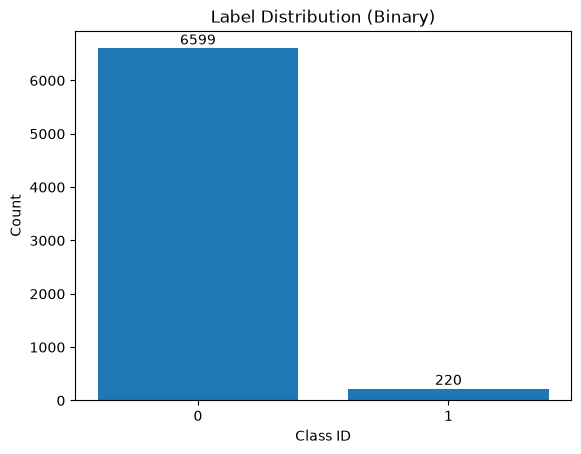

In [38]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

label       = data["Bankrupt?"]
label_count = label.value_counts()

plt.bar(label_count.keys(), label_count.values, 0.8)
plt.title("Label Distribution (Binary)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.xticks([0, 1])

for cls_id, count in label_count.items():
    count_str = str(count)
    plt.text(cls_id, count+75, count_str, ha="center")
    
plt.show()

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


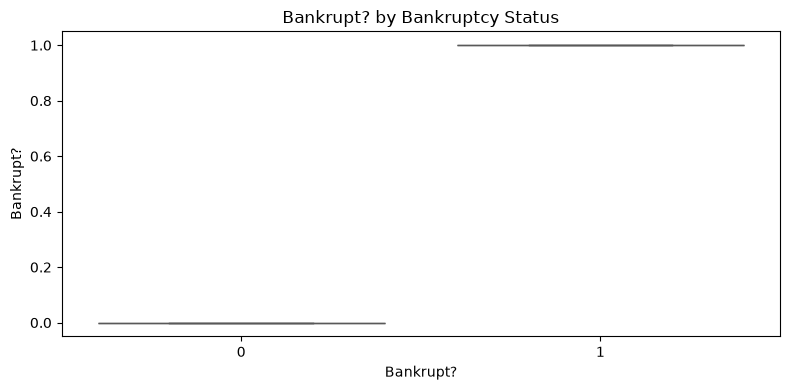

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


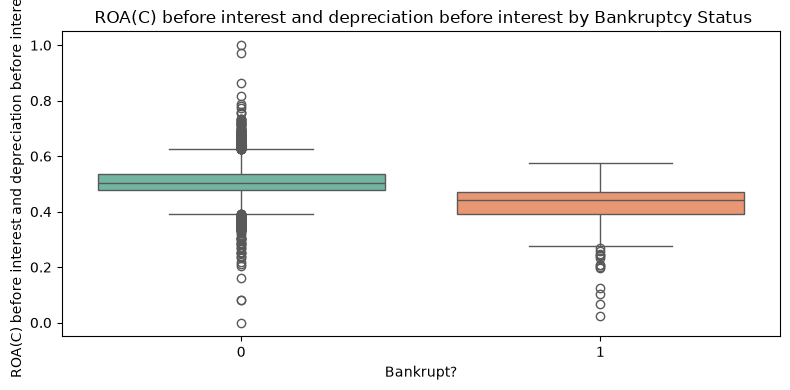

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


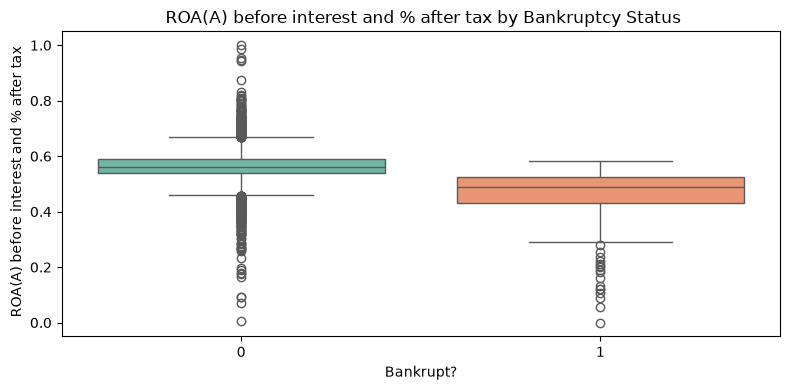

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


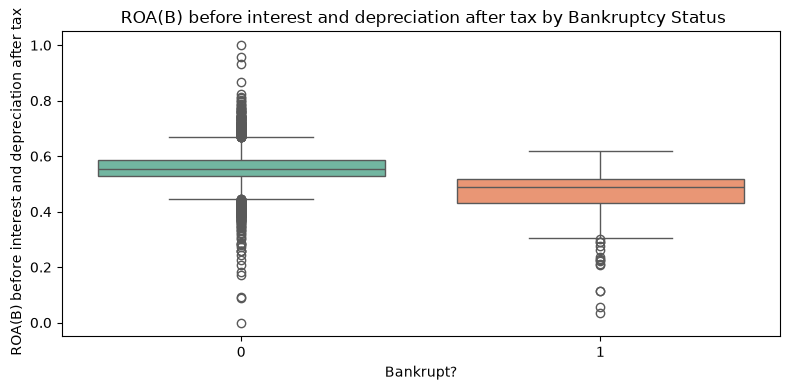

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


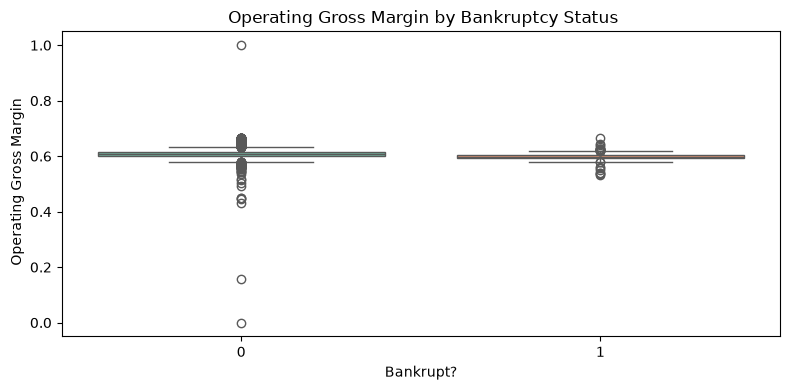

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


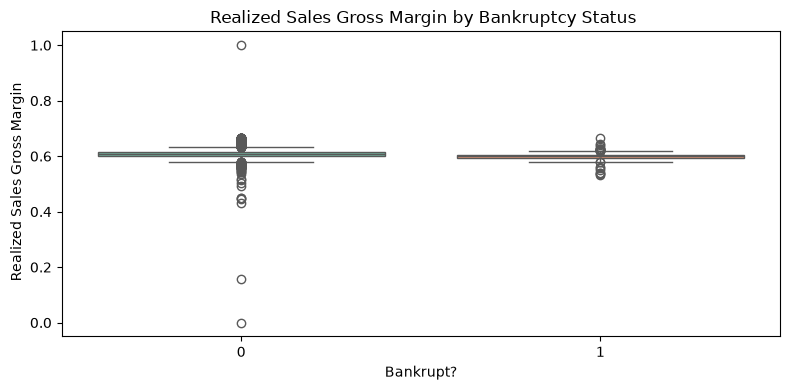

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


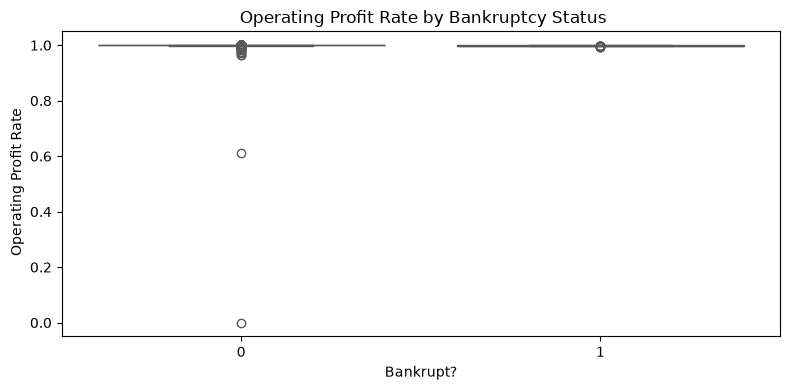

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


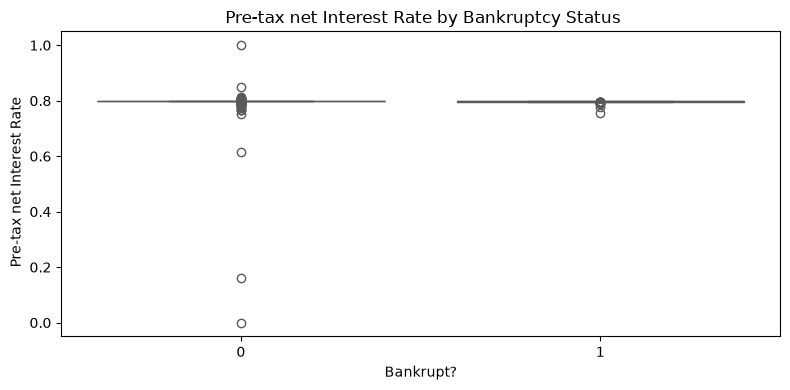

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


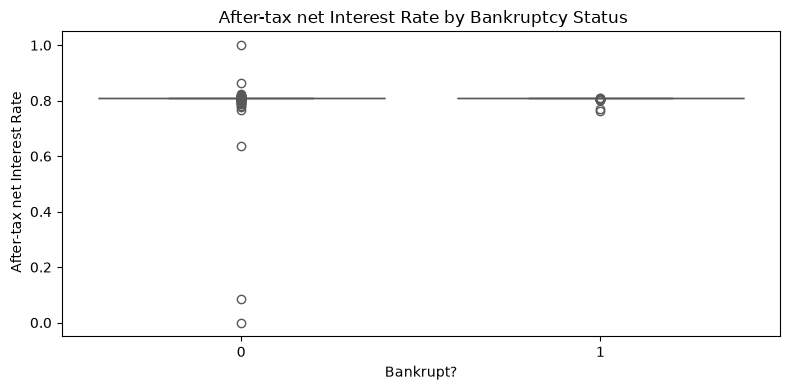

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


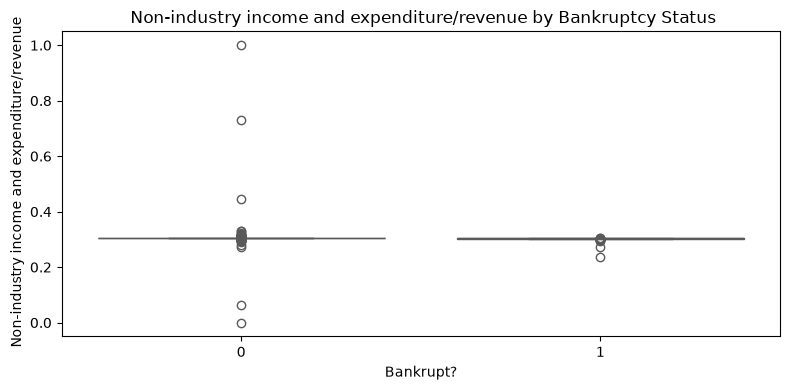

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


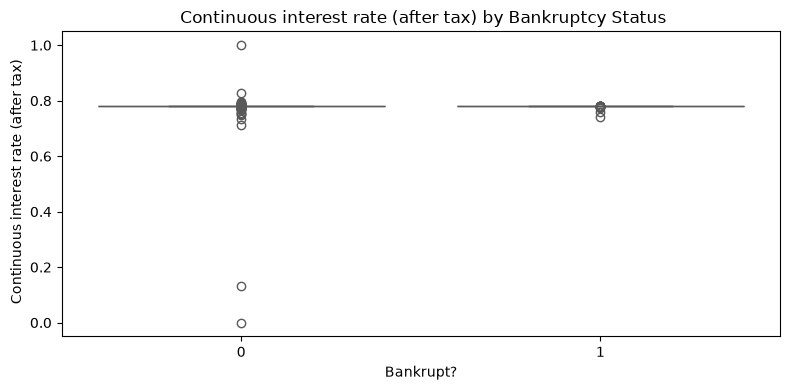

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


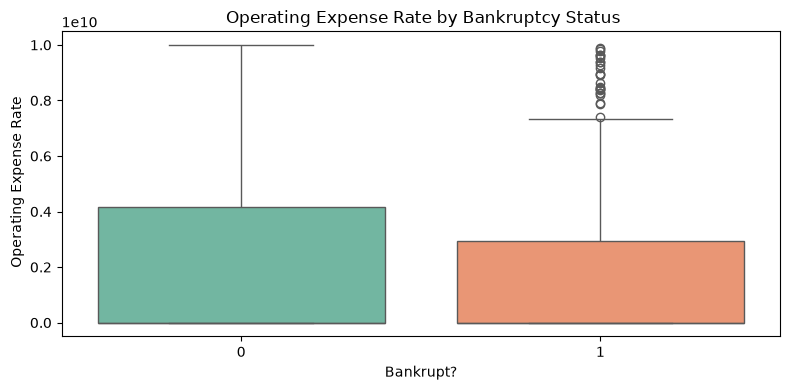

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


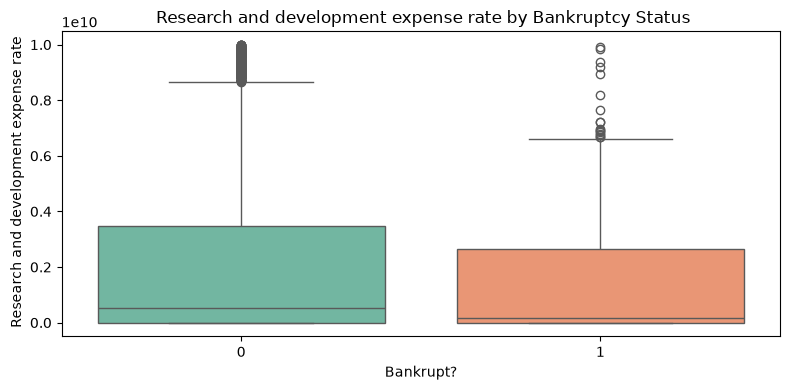

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


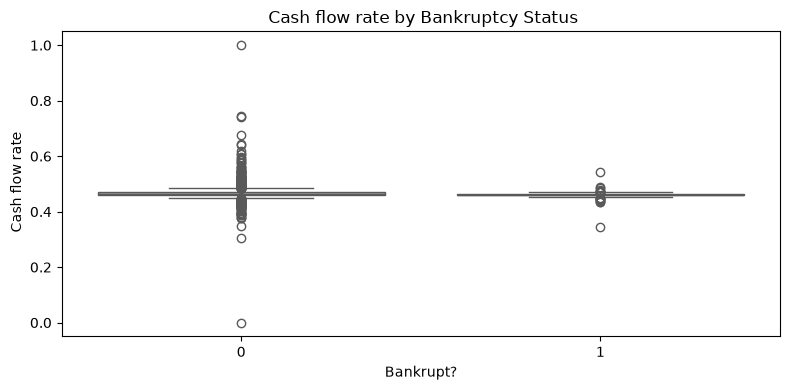

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


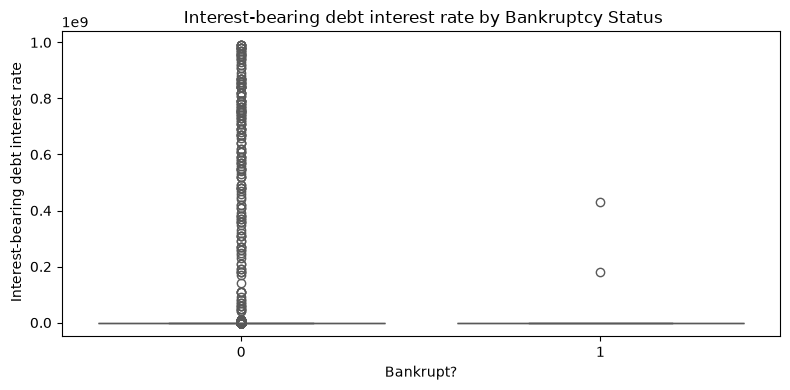

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


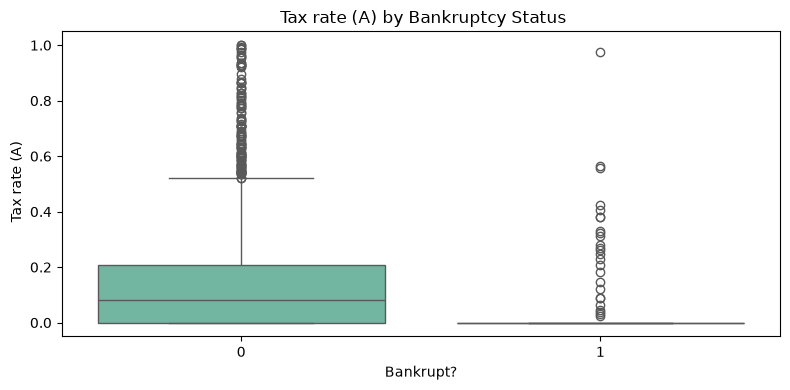

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


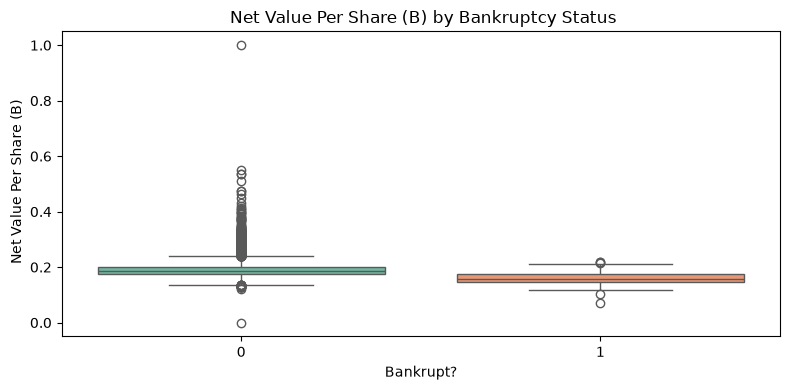

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


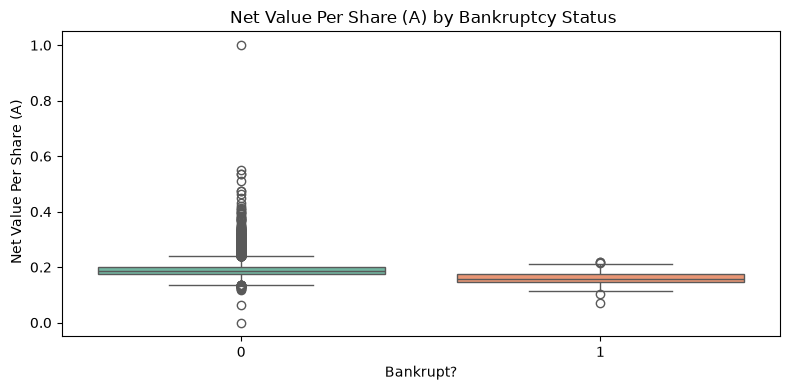

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


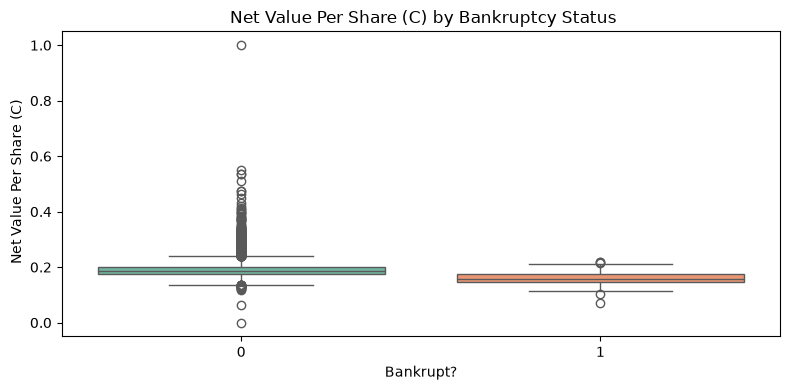

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


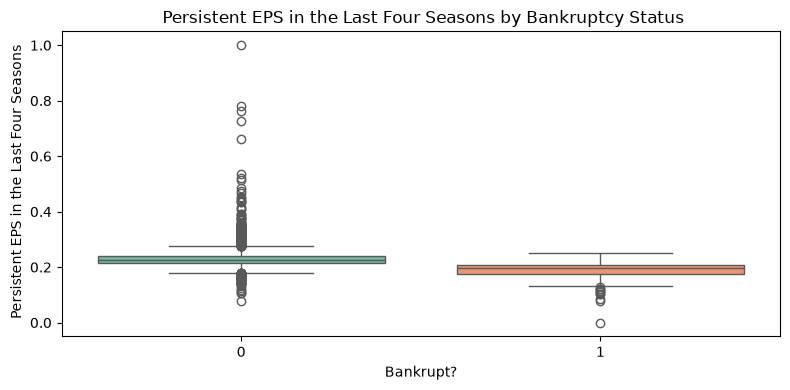

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


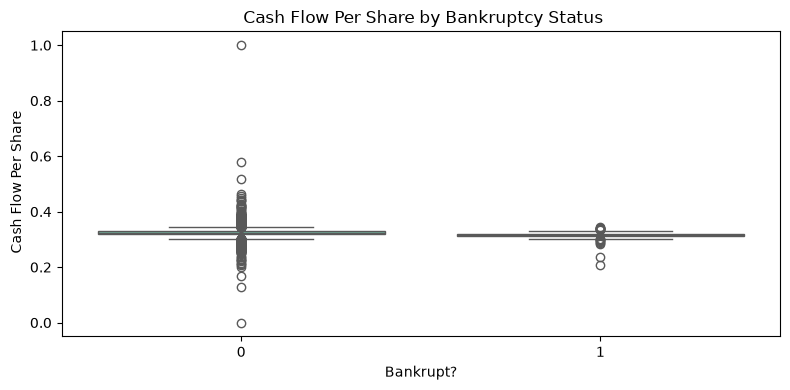

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


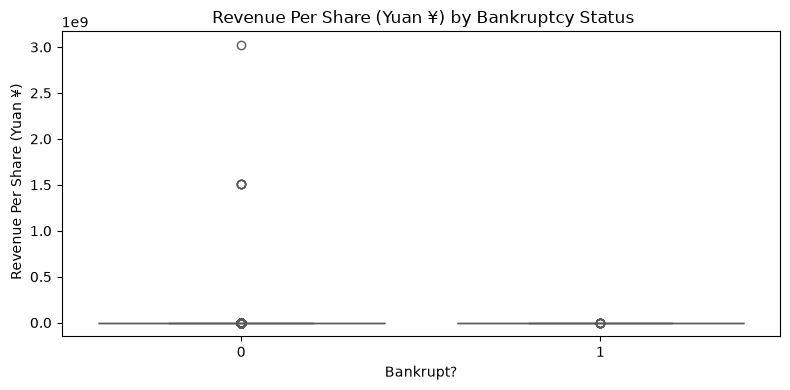

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


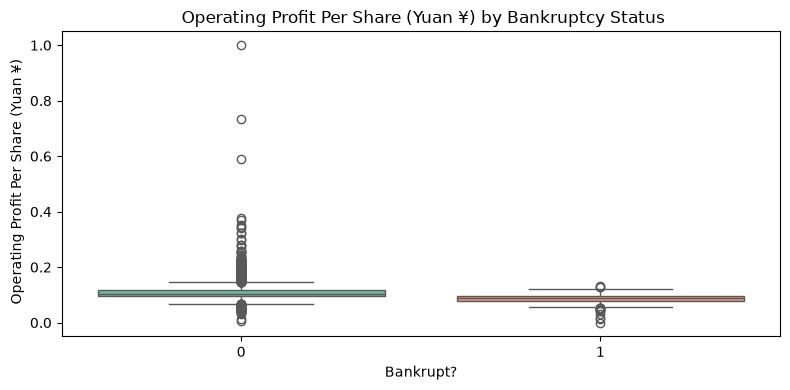

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


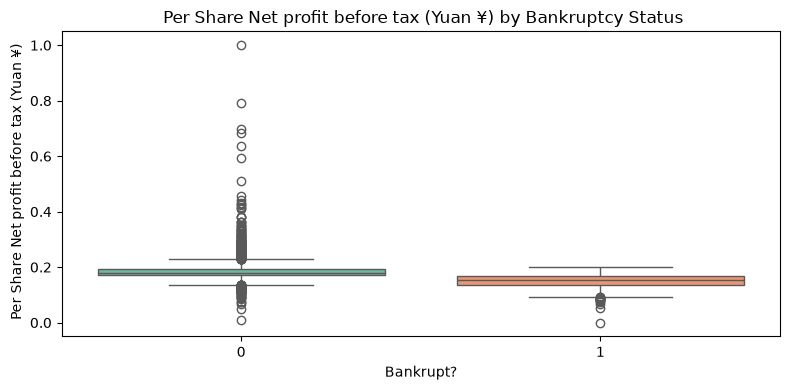

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


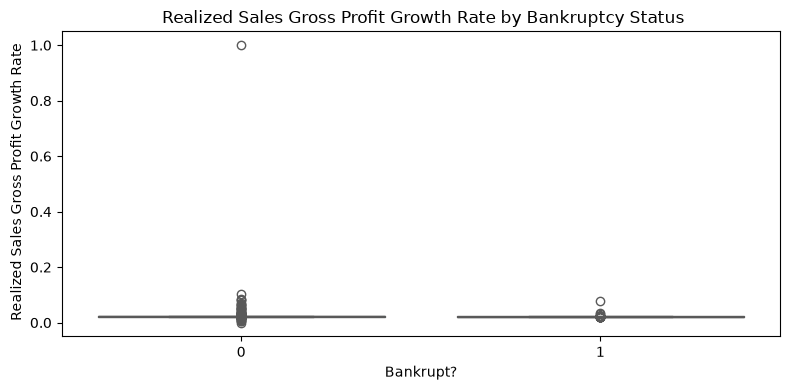

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


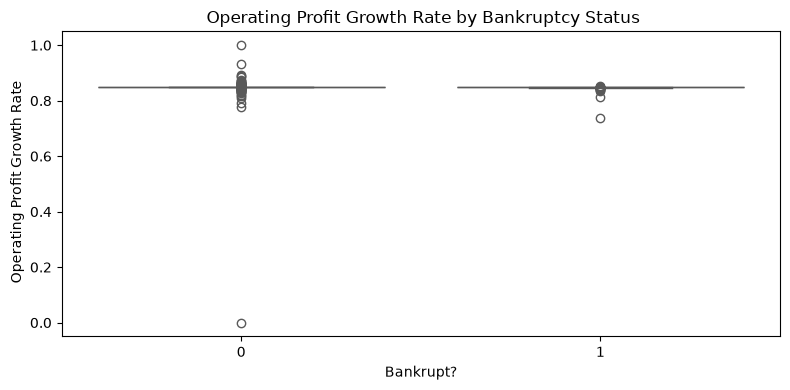

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


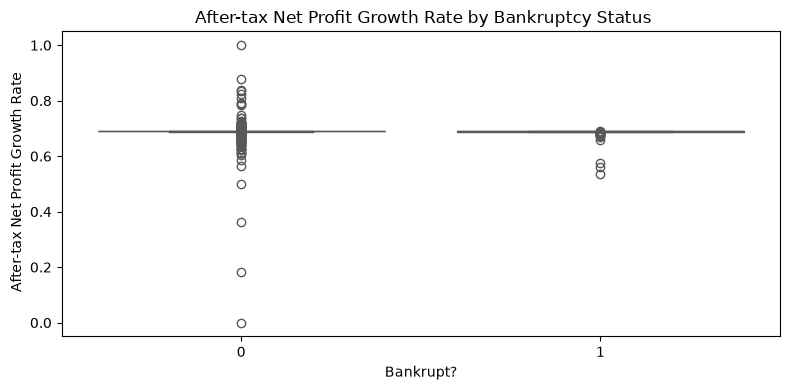

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


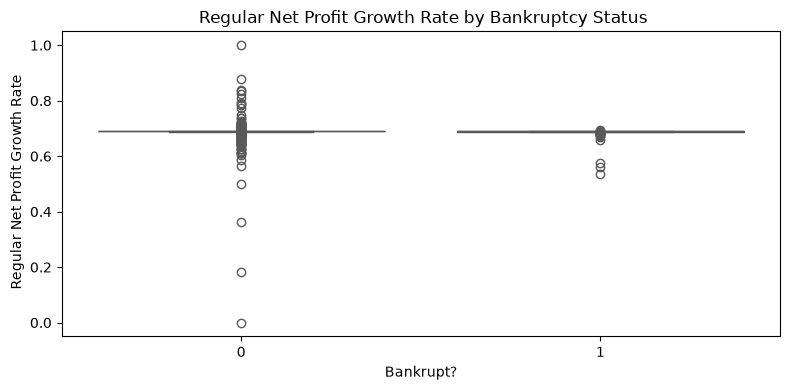

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


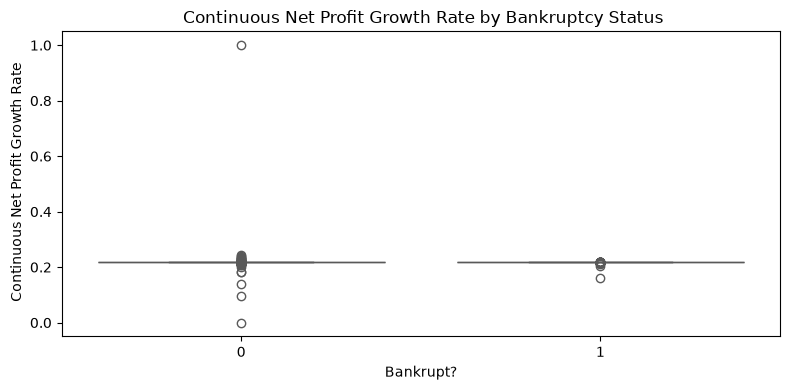

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


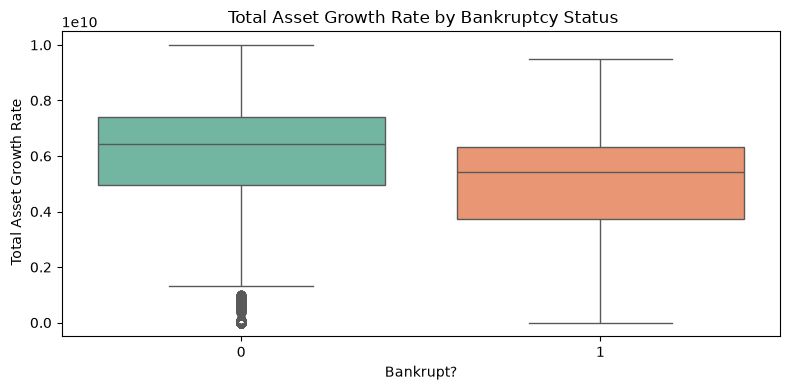

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


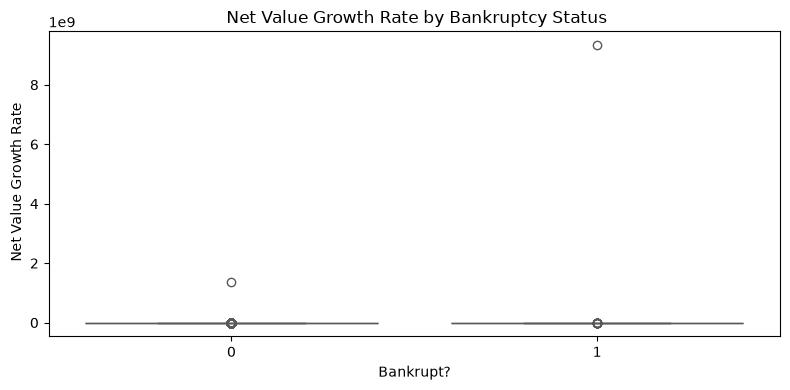

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


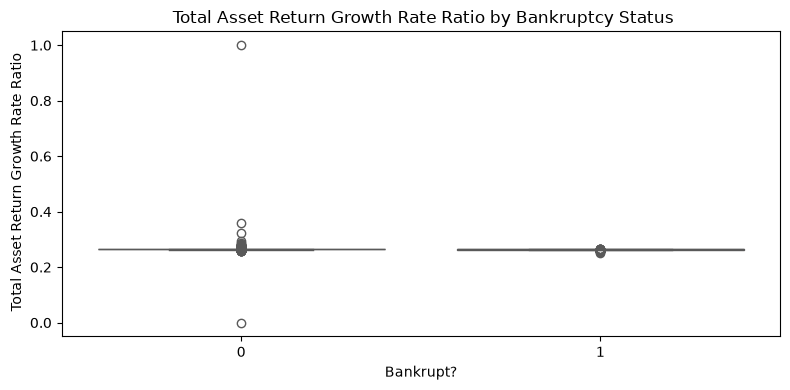

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


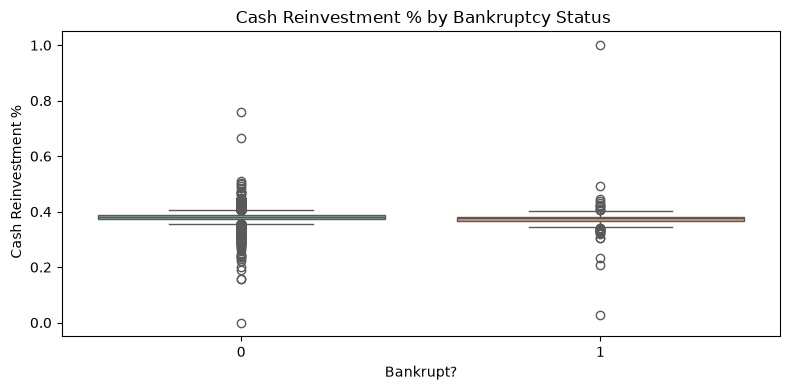

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


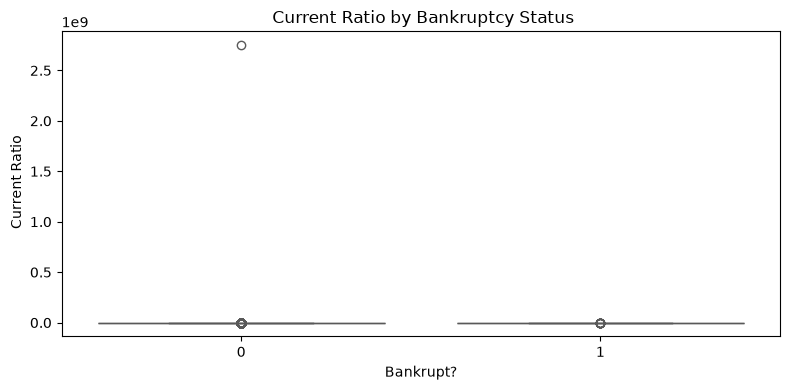

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


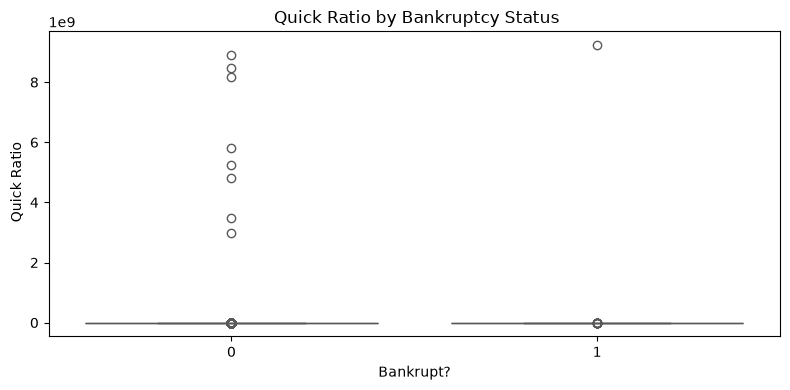

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


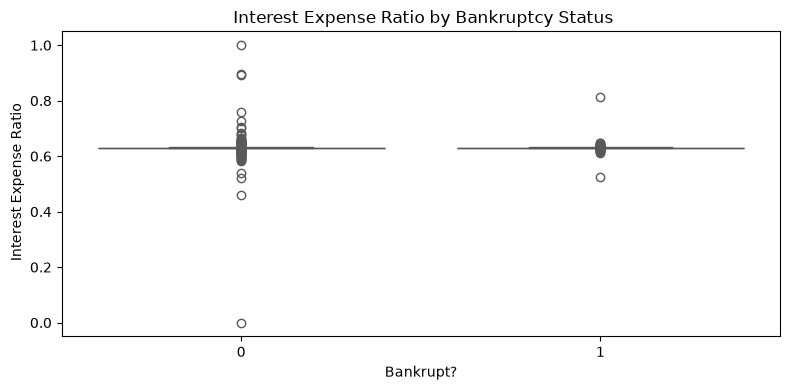

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


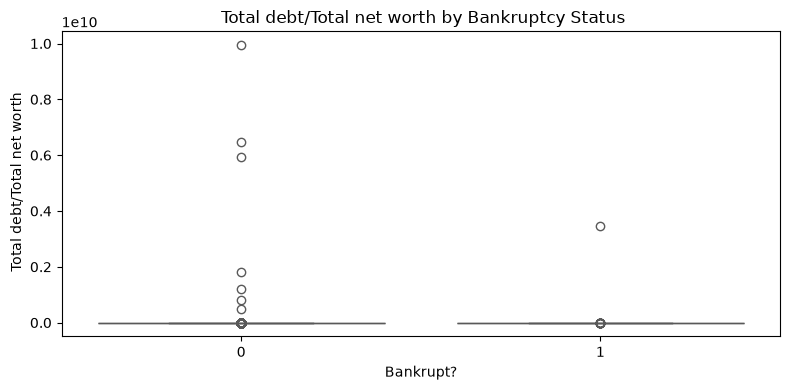

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


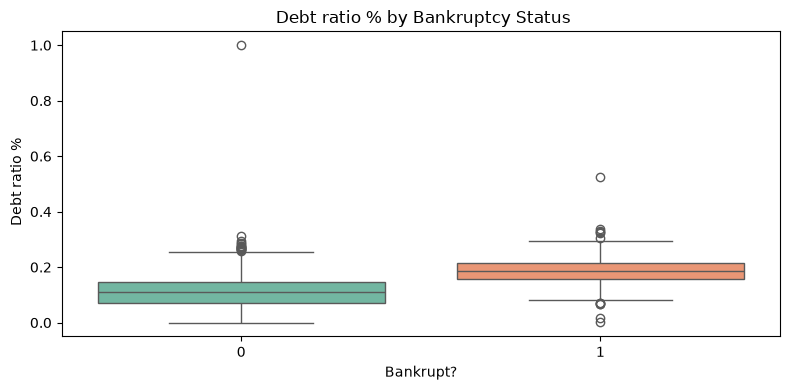

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


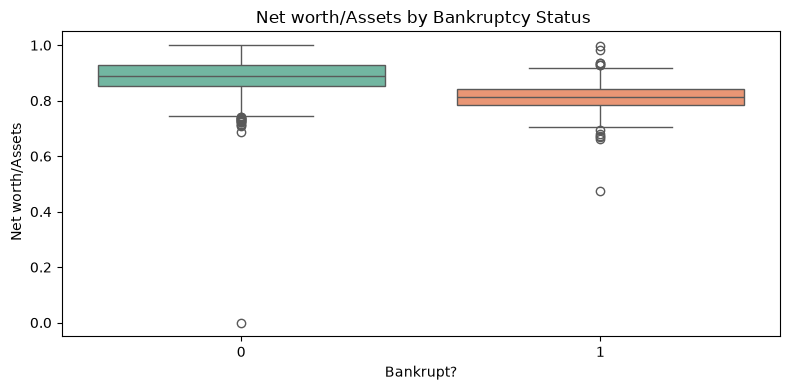

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


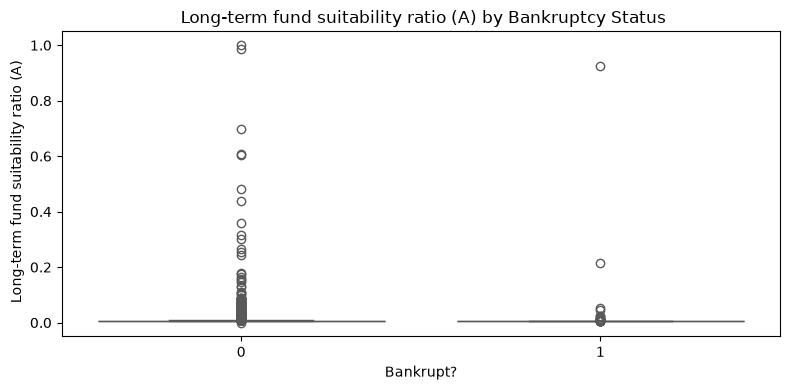

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


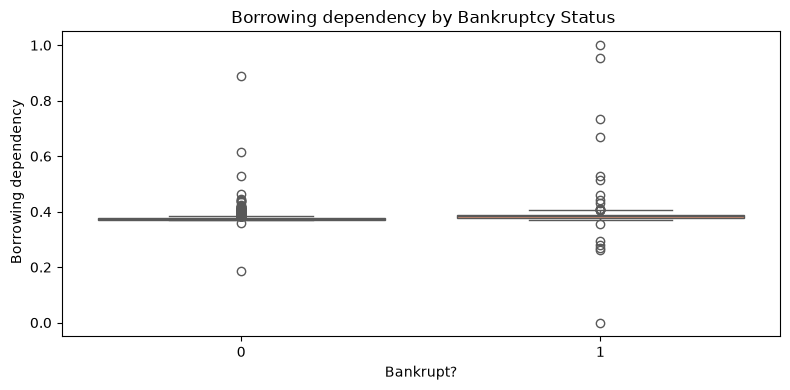

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


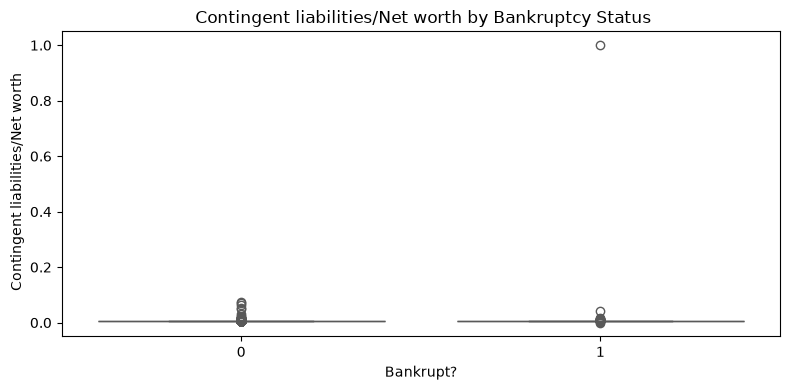

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


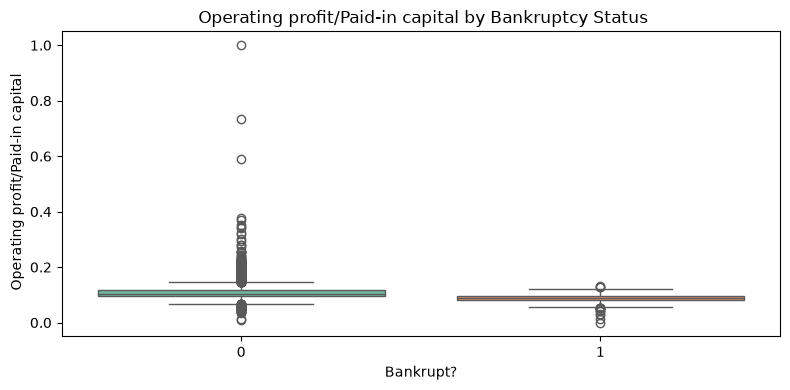

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


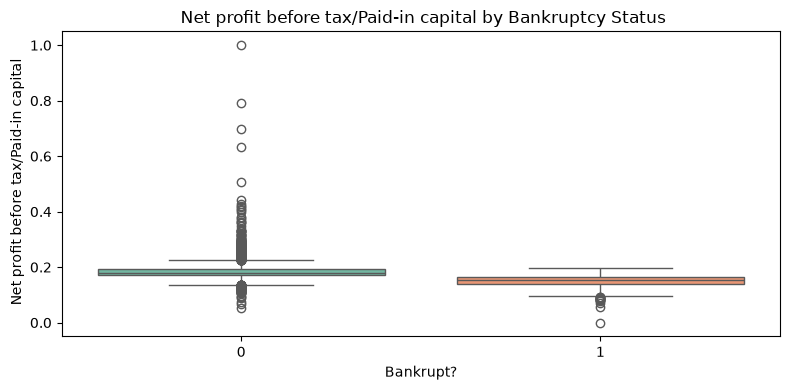

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


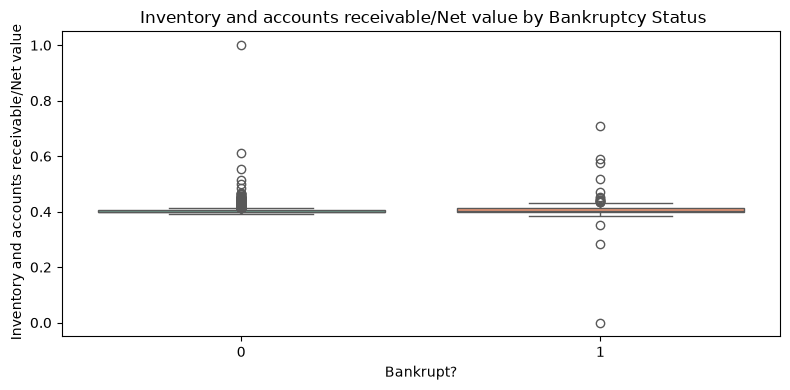

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


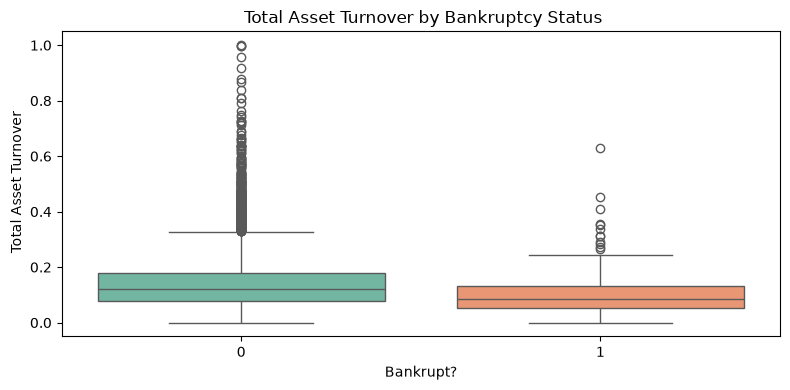

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


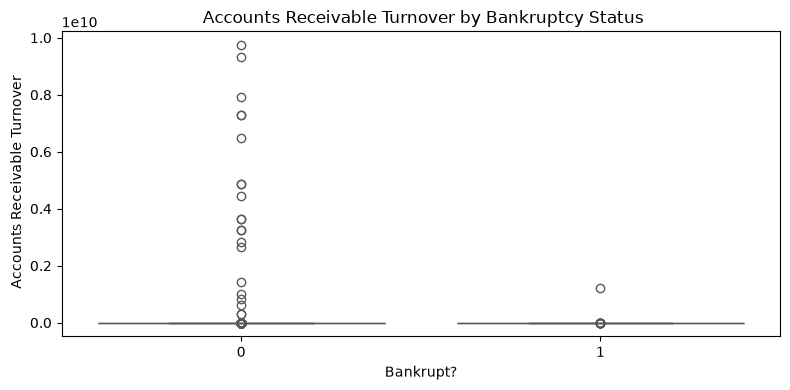

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


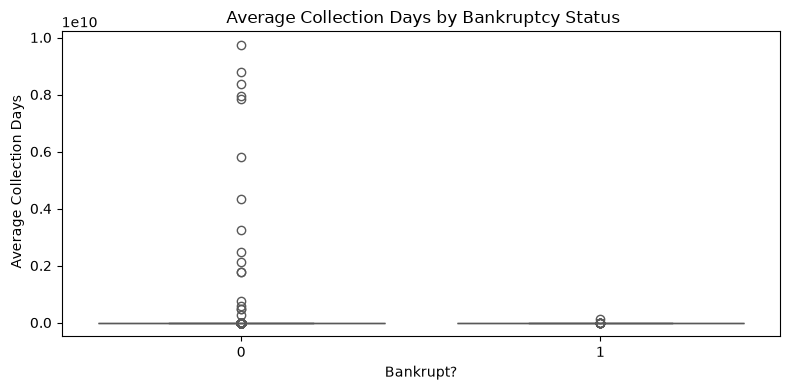

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


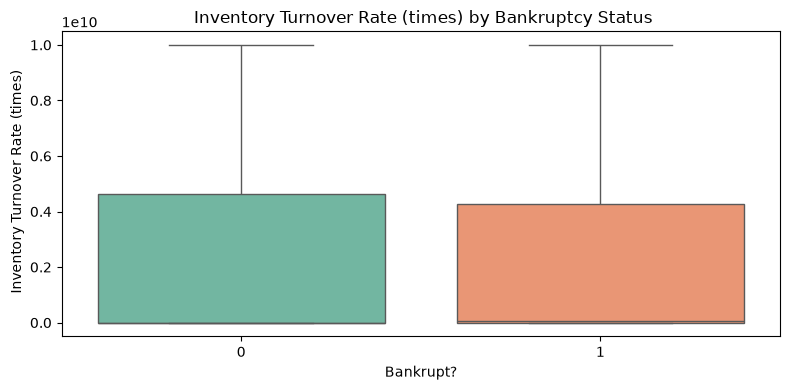

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


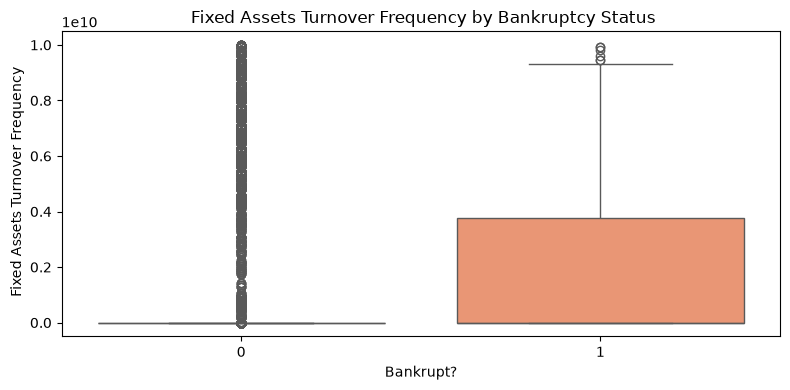

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


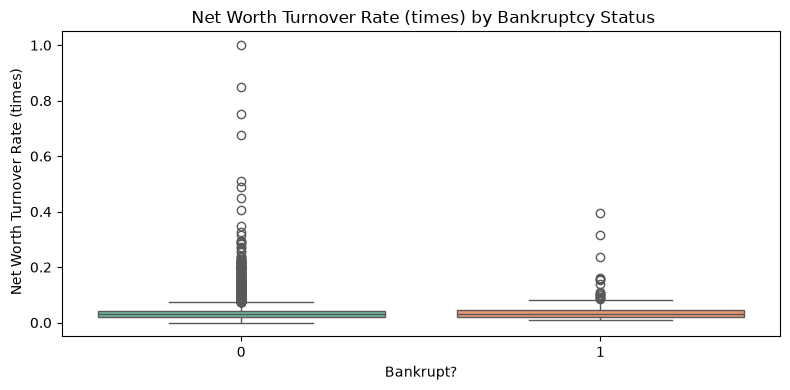

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


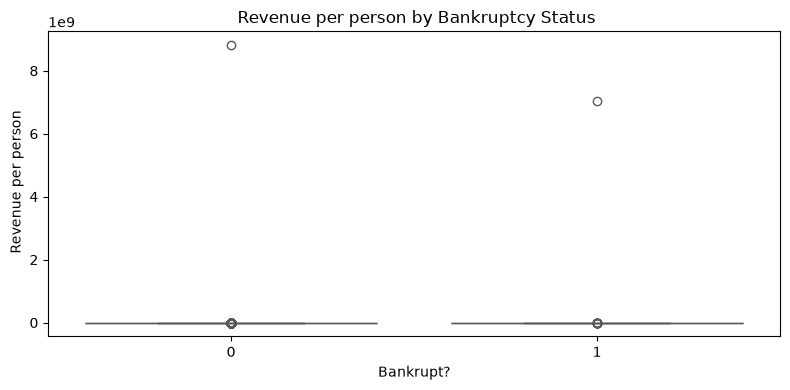

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


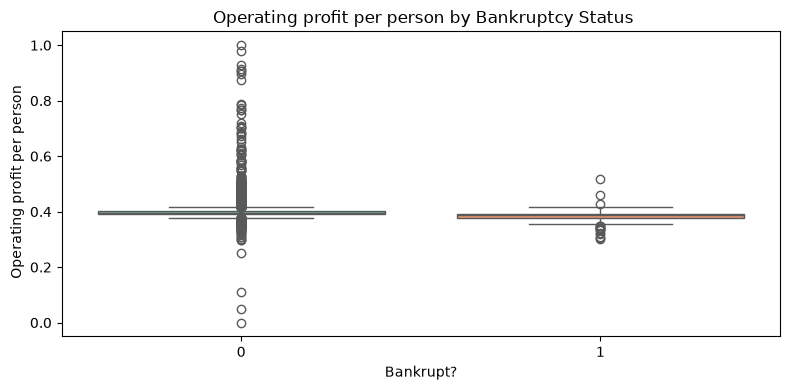

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


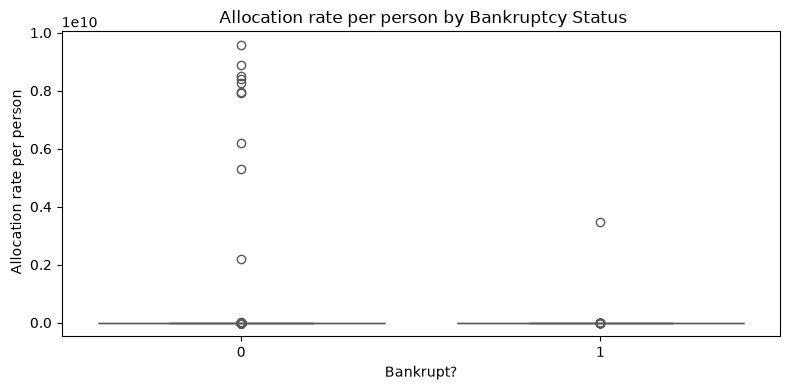

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


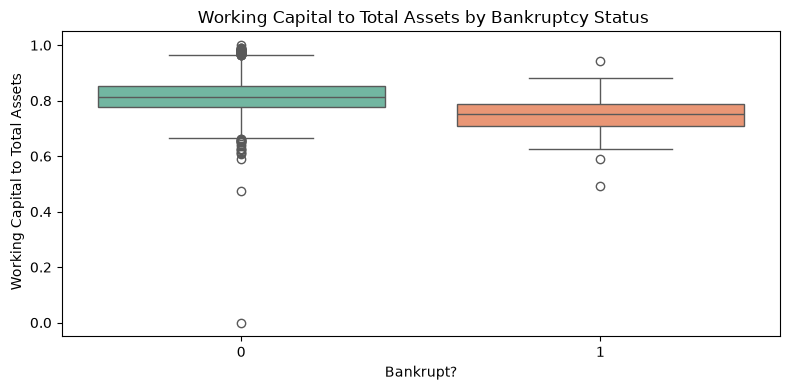

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


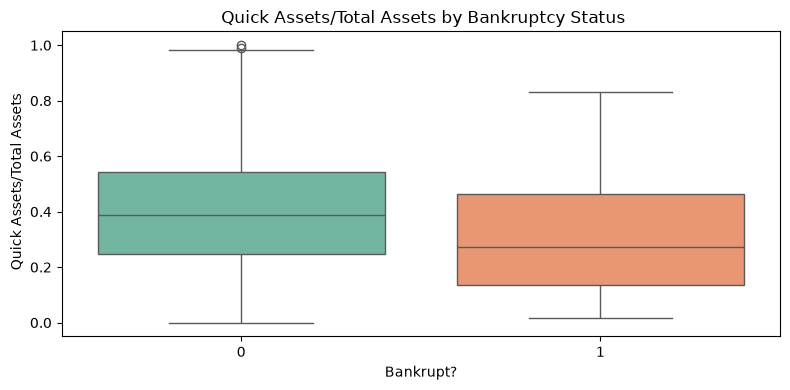

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


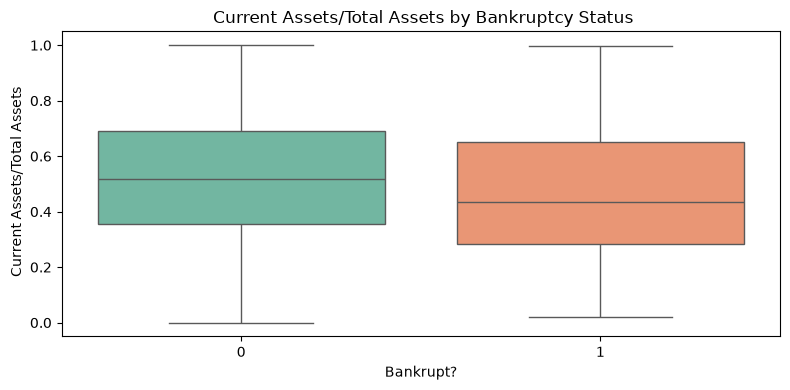

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


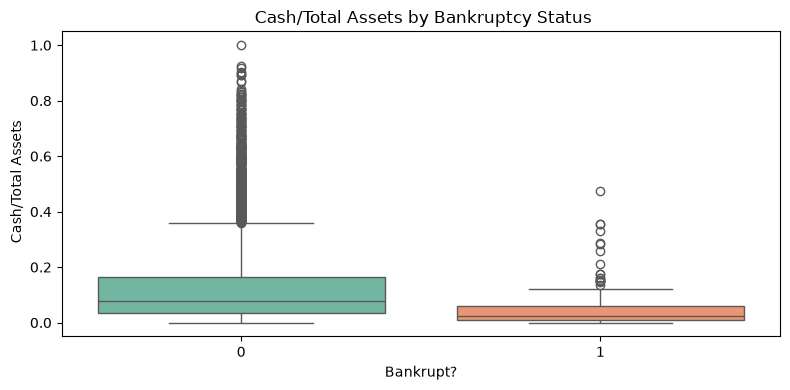

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


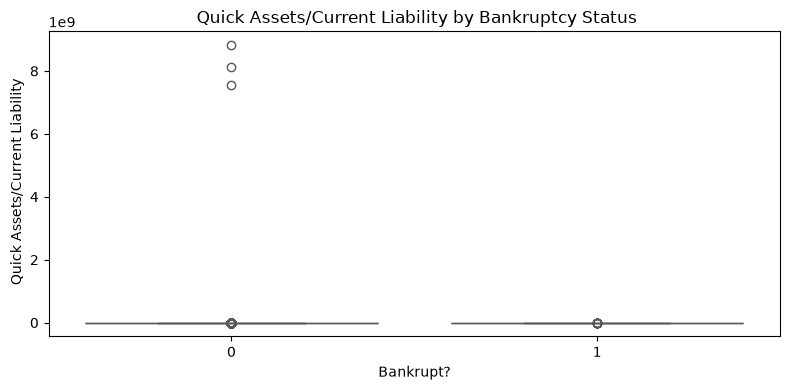

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


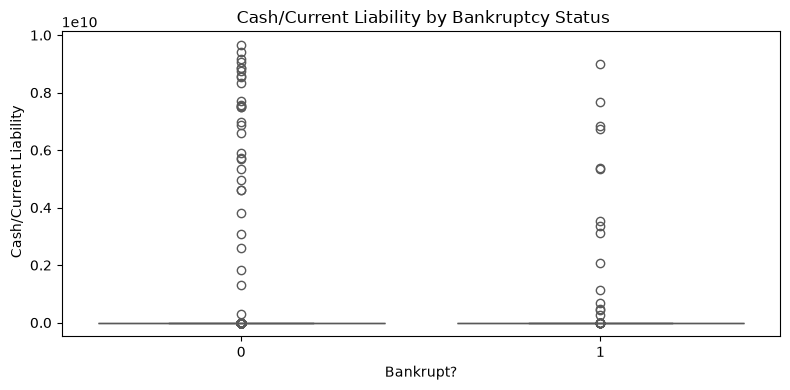

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


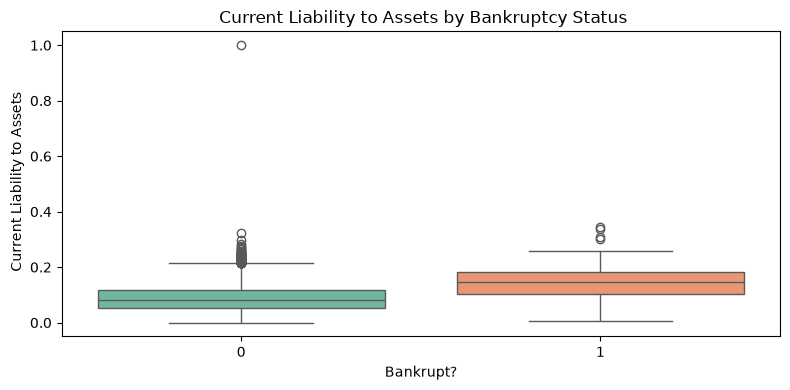

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


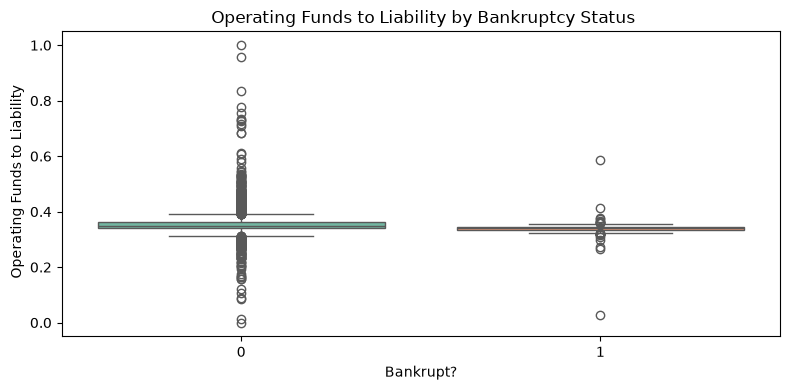

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


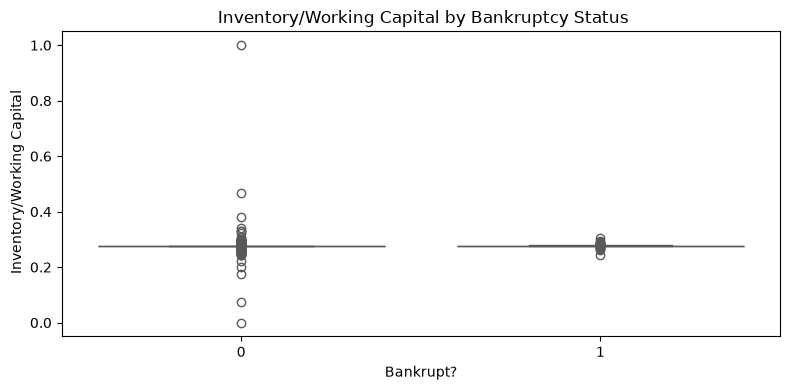

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


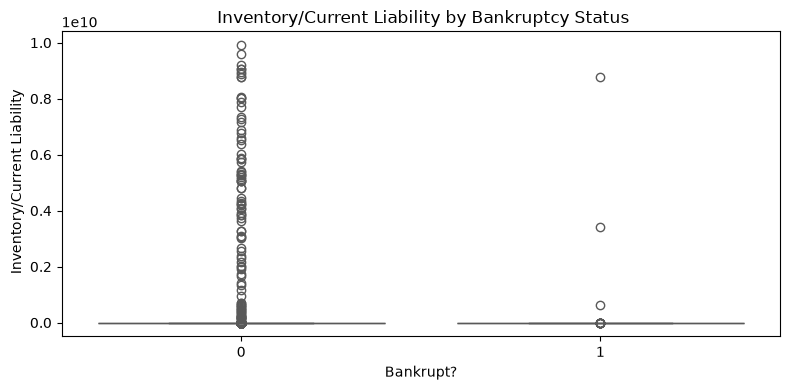

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


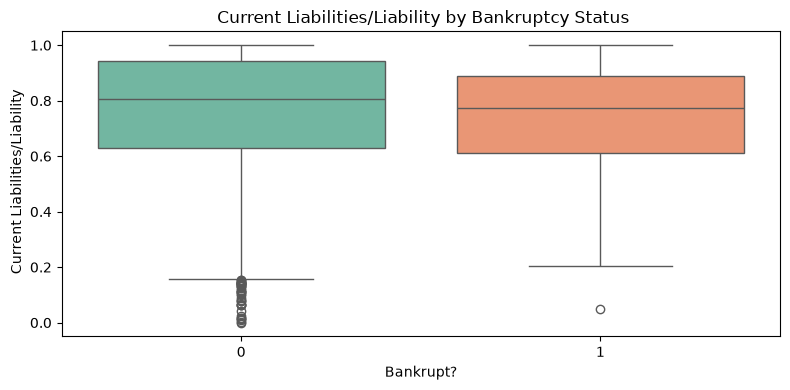

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


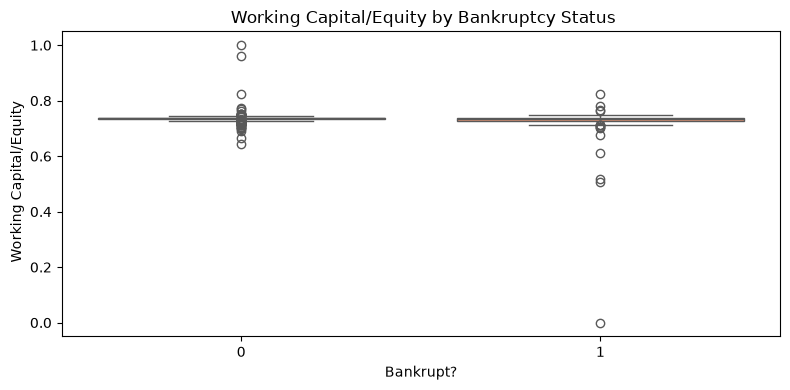

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


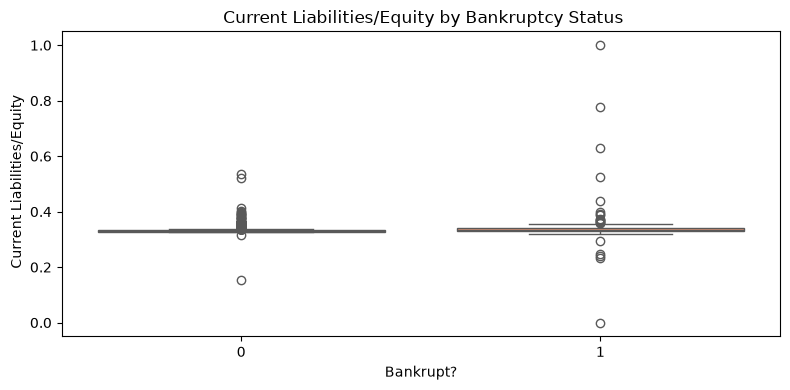

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


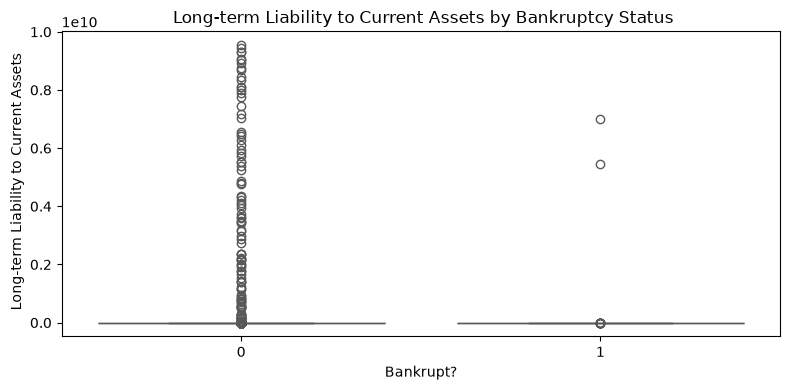

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


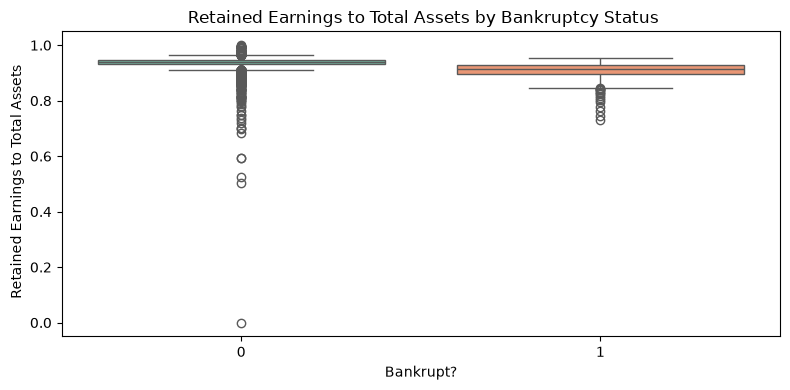

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


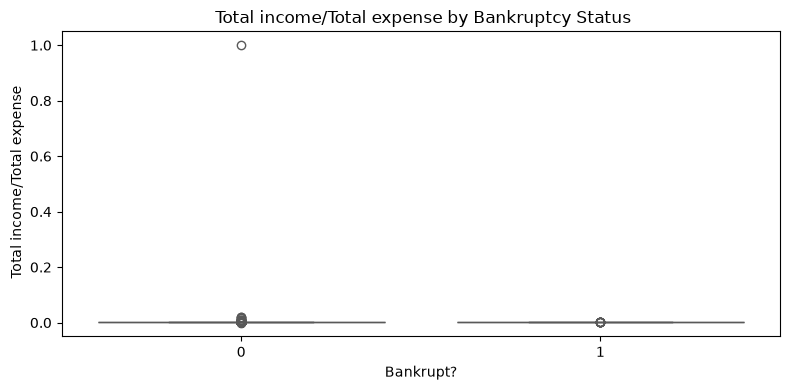

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


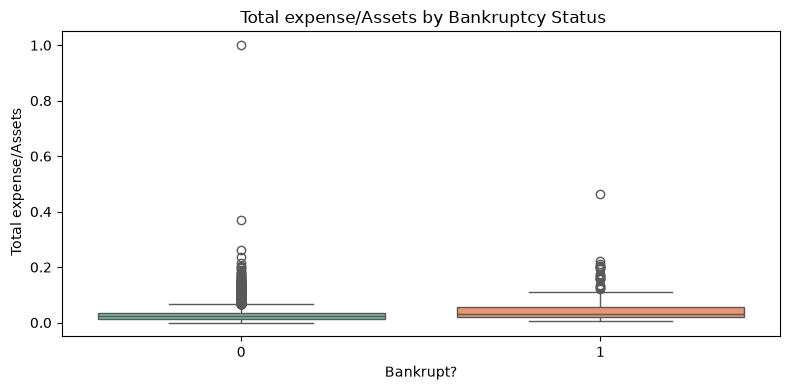

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


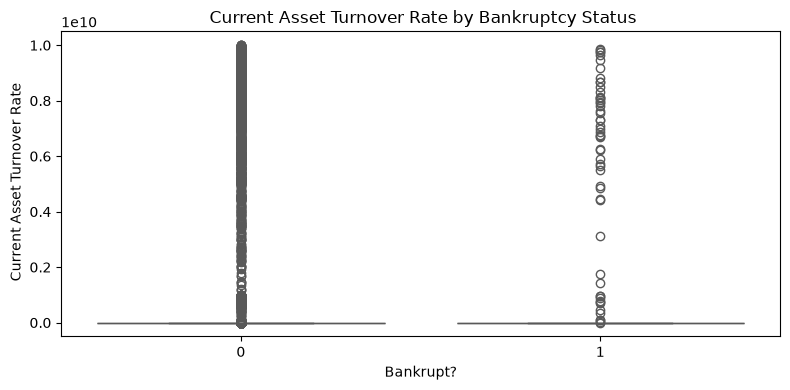

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


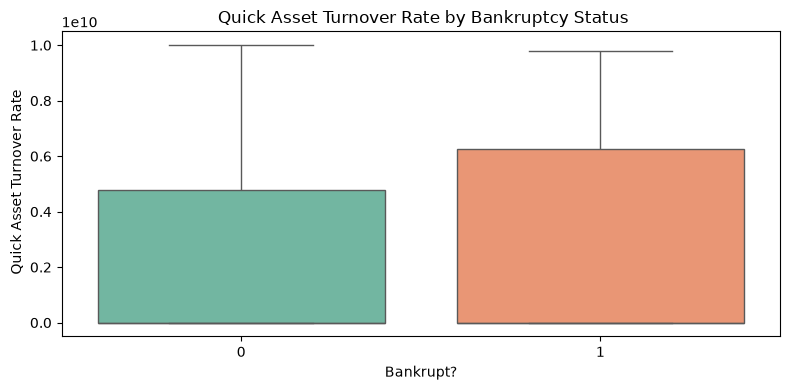

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


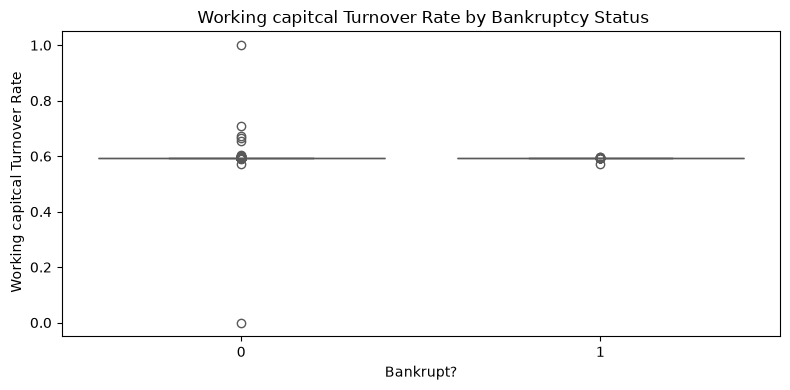

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


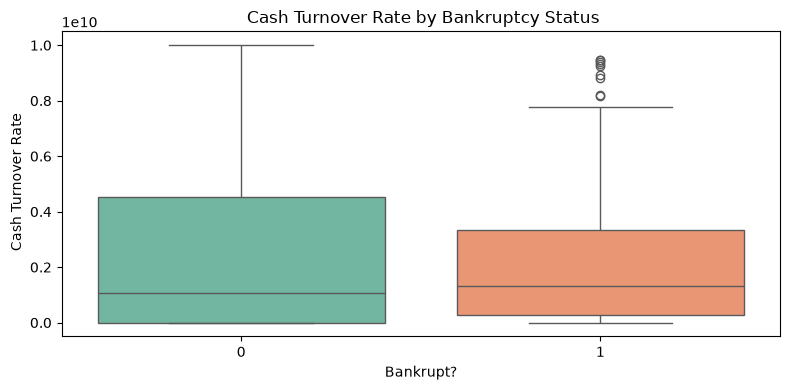

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


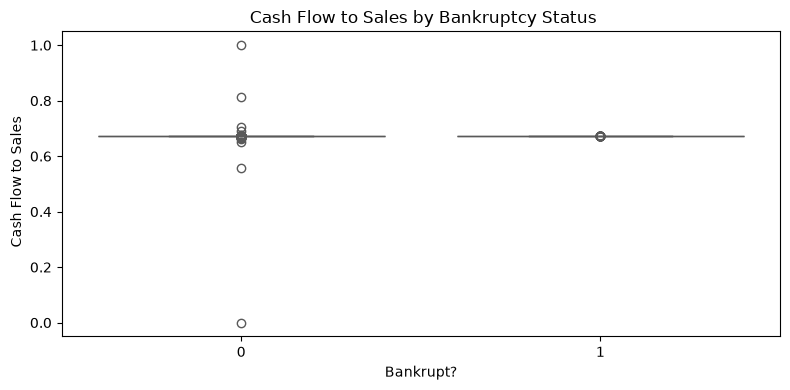

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


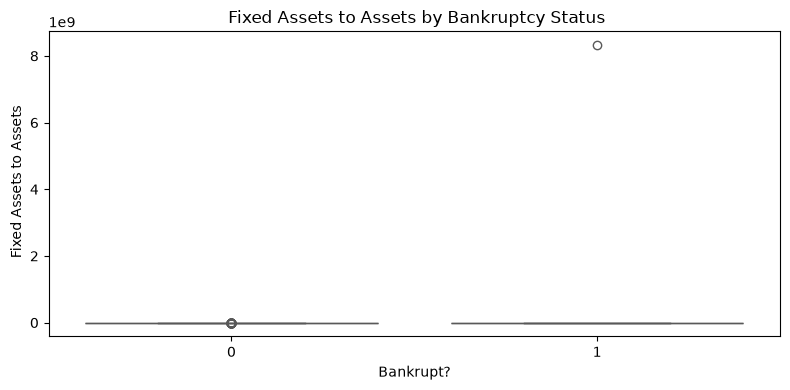

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


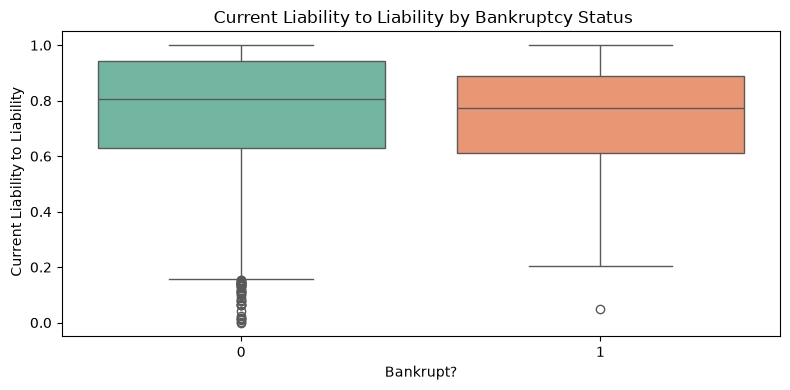

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


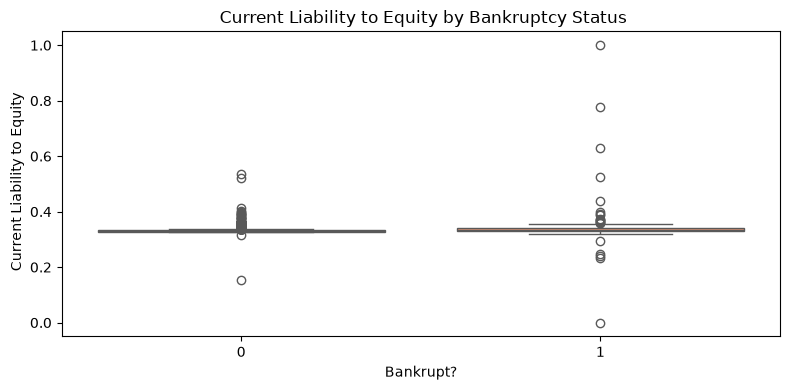

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


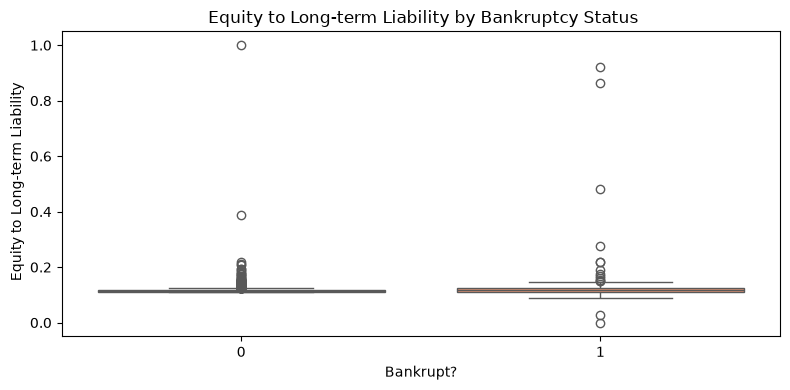

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


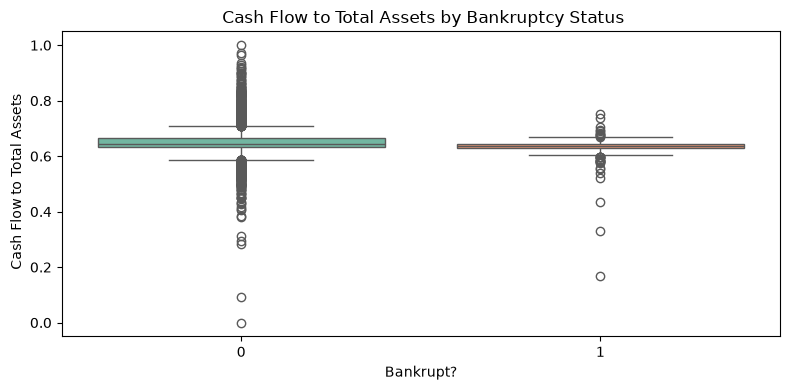

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


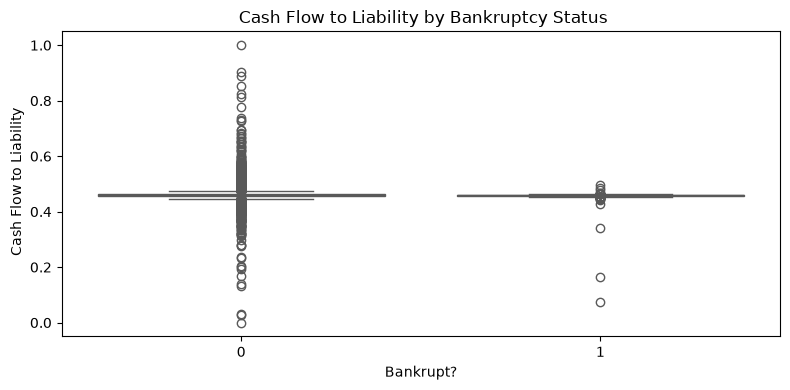

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


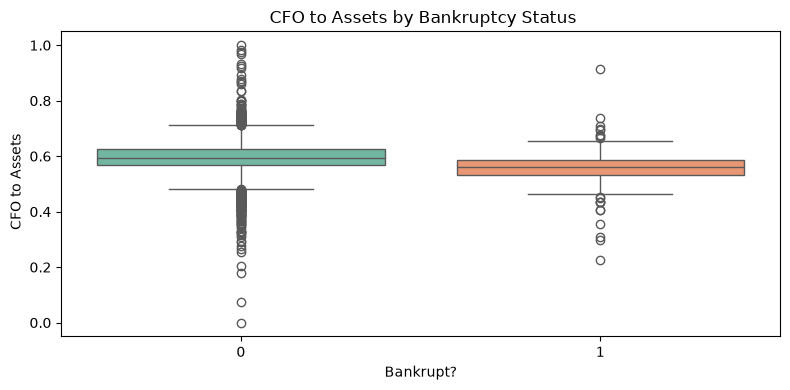

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


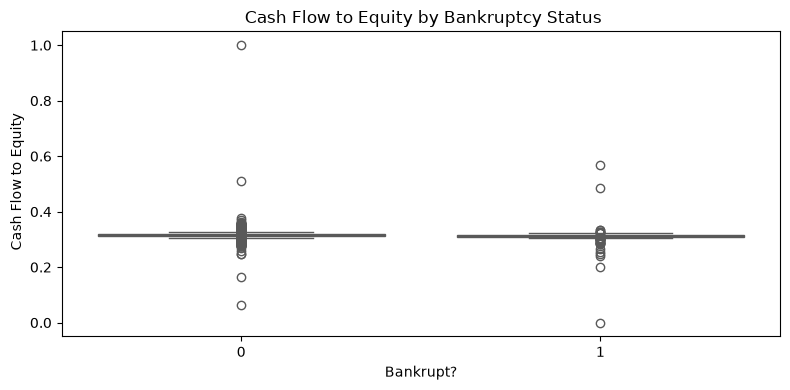

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


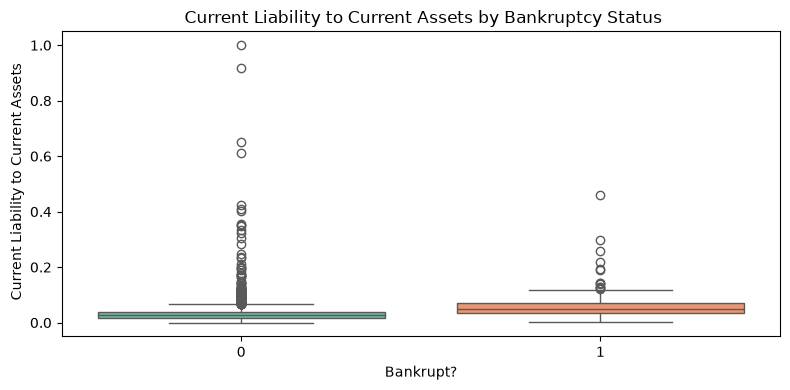

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


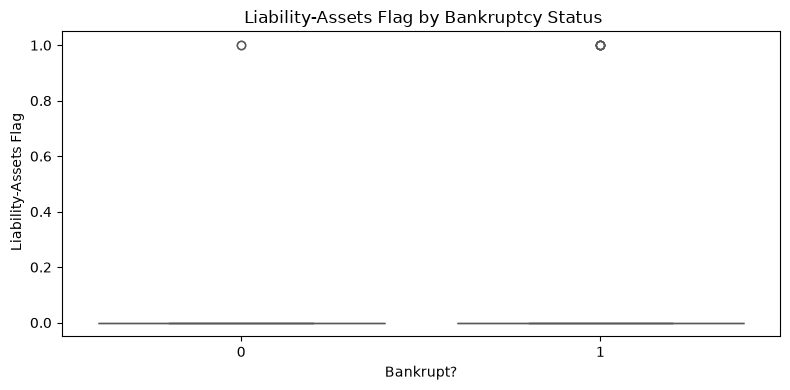

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


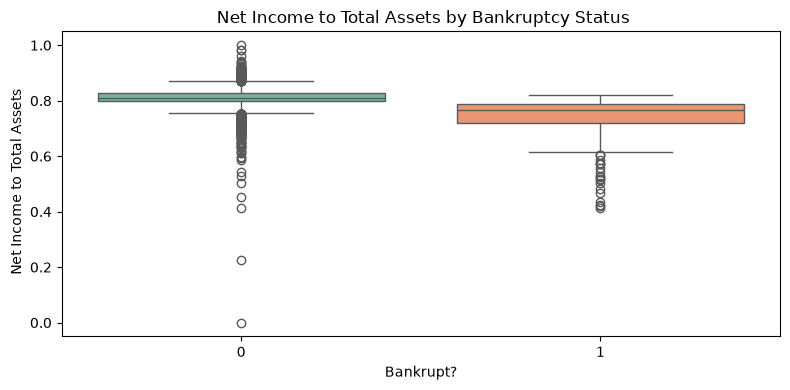

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


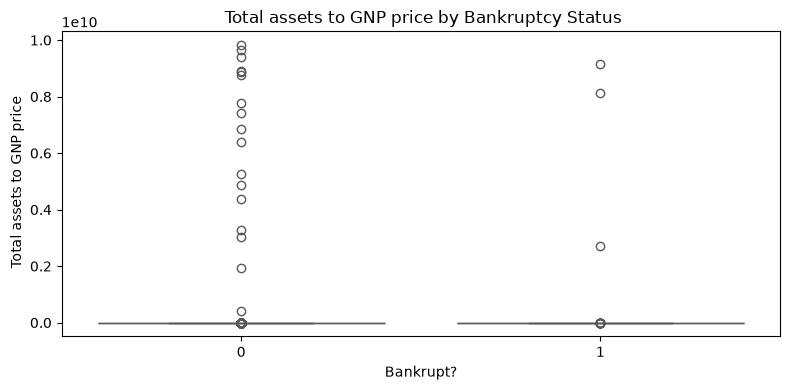

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


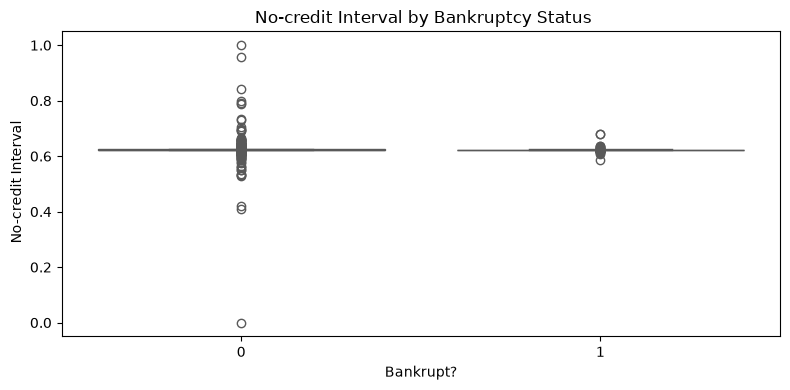

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


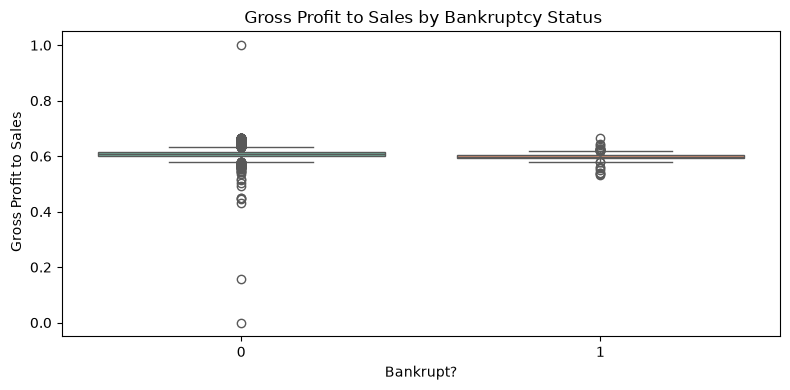

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


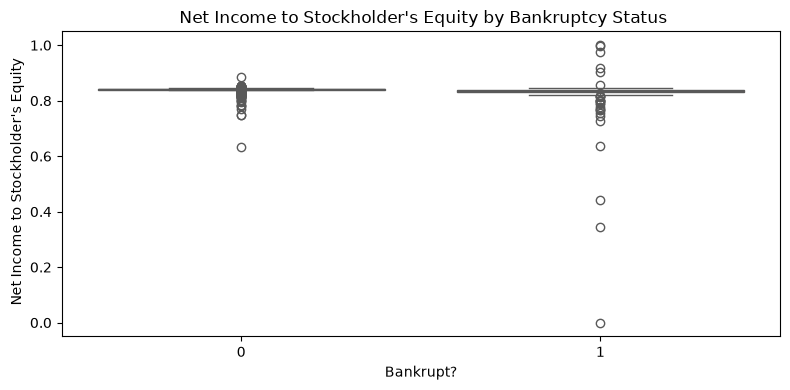

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


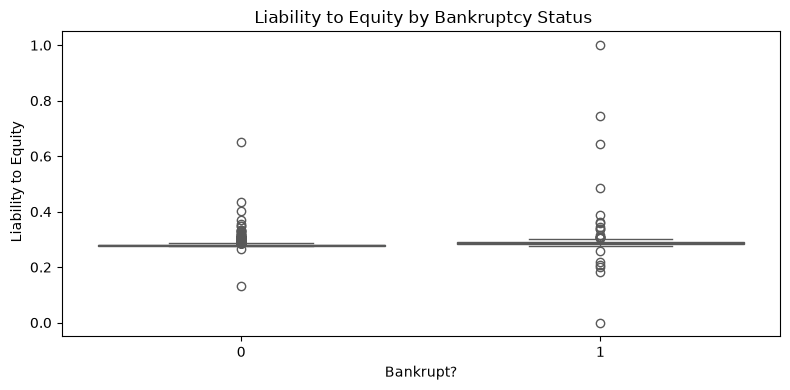

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


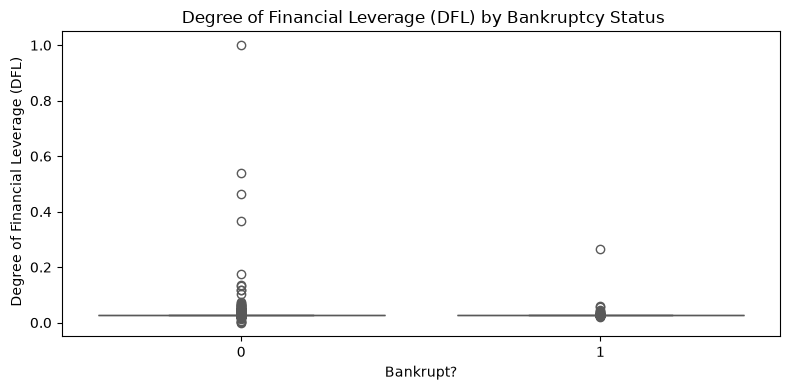

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


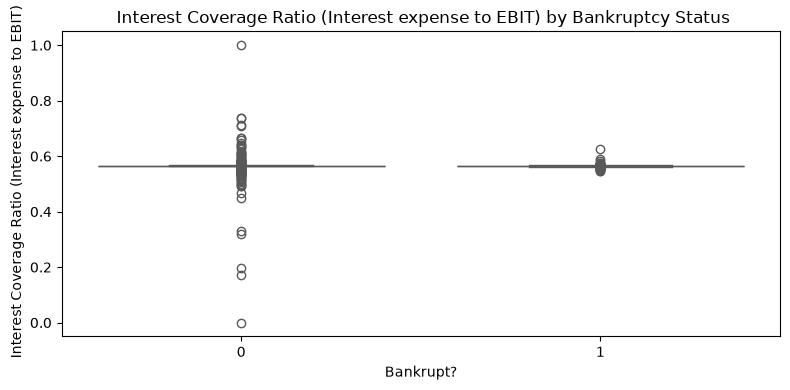

/tmp/ipykernel_33402/2245269146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')


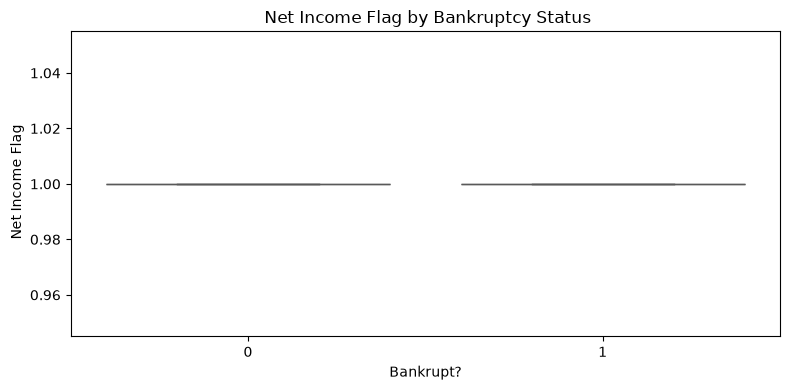

In [39]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

for col in data.columns[:-1]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x='Bankrupt?', y=col, palette='Set2')
    plt.title(f'{col} by Bankruptcy Status')
    plt.xlabel('Bankrupt?')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [40]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print("No missing values detected; preprocessing step is skipped.")
# Dataset ini tidak memiliki nilai hilang, jadi tidak perlu imputasi.

No missing values detected; preprocessing step is skipped.


In [41]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

print("All features are already numeric; no additional encoding is required.")
# Dataset finansial ini sudah berupa numerik, sehingga tidak perlu encoding tambahan.

All features are already numeric; no additional encoding is required.


In [42]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data.drop(columns=['Bankrupt?'])
y = data['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True).sort_index())

Train shape: (5455, 95)
Test shape: (1364, 95)
Train class distribution:
 Bankrupt?
0    0.967736
1    0.032264
Name: proportion, dtype: float64


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [43]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

gini_pred = dt_gini.predict(X_test)
gini_proba = dt_gini.predict_proba(X_test)[:, 1]
print("Gini model trained successfully.")


Gini model trained successfully.


In [44]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

print("Accuracy Gini:", accuracy_score(y_test, gini_pred))
print(classification_report(y_test, gini_pred, target_names=['Non-Bankrupt', 'Bankrupt']))

Accuracy Gini: 0.9611436950146628
              precision    recall  f1-score   support

Non-Bankrupt       0.98      0.98      0.98      1320
    Bankrupt       0.40      0.41      0.40        44

    accuracy                           0.96      1364
   macro avg       0.69      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364



## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [45]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

entropy_pred = dt_entropy.predict(X_test)
entropy_proba = dt_entropy.predict_proba(X_test)[:, 1]
print("Entropy model trained successfully.")


Entropy model trained successfully.


In [46]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

print("Accuracy Entropy:", accuracy_score(y_test, entropy_pred))
print(classification_report(y_test, entropy_pred, target_names=['Non-Bankrupt', 'Bankrupt']))

Accuracy Entropy: 0.9640762463343109
              precision    recall  f1-score   support

Non-Bankrupt       0.98      0.98      0.98      1320
    Bankrupt       0.44      0.39      0.41        44

    accuracy                           0.96      1364
   macro avg       0.71      0.68      0.70      1364
weighted avg       0.96      0.96      0.96      1364



## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [47]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

max_depth_values = [1, 2, 3, 5, 10, None]
train_acc = []
test_acc = []

for depth in max_depth_values:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

    if depth == None:
        max_depth_values[-1] = model.get_depth()

print("max_depth vs accuracy:")
for depth, tr_acc, te_acc in zip(max_depth_values, train_acc, test_acc):
    print(f"depth={depth} -> train={tr_acc:.4f}, test={te_acc:.4f}")

max_depth vs accuracy:
depth=1 -> train=0.9677, test=0.9677
depth=2 -> train=0.9699, test=0.9699
depth=3 -> train=0.9723, test=0.9699
depth=5 -> train=0.9775, test=0.9685
depth=10 -> train=0.9947, test=0.9604
depth=20 -> train=1.0000, test=0.9611


In [48]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

depth_summary = pd.DataFrame({
    'max_depth': max_depth_values,
    'train_accuracy': train_acc,
    'test_accuracy': test_acc,
})

print(depth_summary)

   max_depth  train_accuracy  test_accuracy
0          1        0.967736       0.967742
1          2        0.969936       0.969941
2          3        0.972319       0.969941
3          5        0.977452       0.968475
4         10        0.994684       0.960411
5         20        1.000000       0.961144


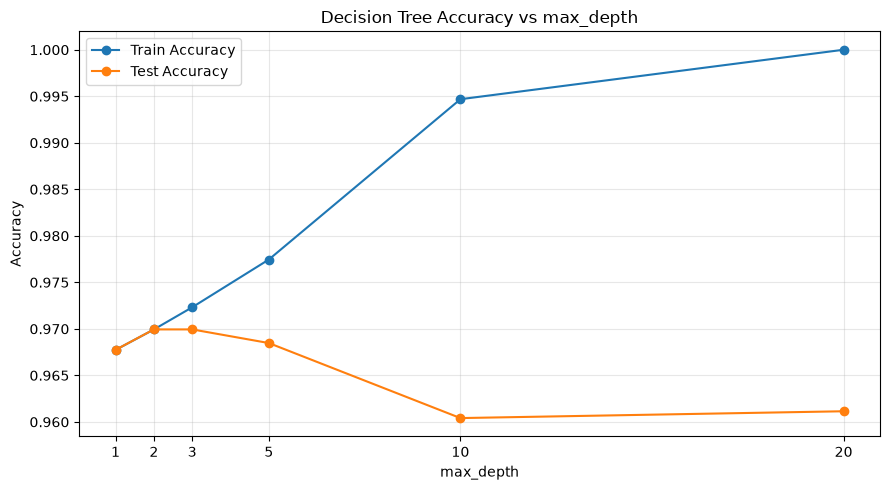

In [49]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

plt.figure(figsize=(9, 5))
plt.plot(depth_summary['max_depth'], depth_summary['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(depth_summary['max_depth'], depth_summary['test_accuracy'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs max_depth')
plt.xticks(depth_summary['max_depth'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [50]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

model_results = [
    {
        'Model': 'Gini',
        'Accuracy': accuracy_score(y_test, gini_pred),
        'Precision': precision_score(y_test, gini_pred, zero_division=0),
        'Recall': recall_score(y_test, gini_pred, zero_division=0),
        'F1-Score': f1_score(y_test, gini_pred, zero_division=0),
    },
    {
        'Model': 'Entropy',
        'Accuracy': accuracy_score(y_test, entropy_pred),
        'Precision': precision_score(y_test, entropy_pred, zero_division=0),
        'Recall': recall_score(y_test, entropy_pred, zero_division=0),
        'F1-Score': f1_score(y_test, entropy_pred, zero_division=0),
    },
]

summary_df = pd.DataFrame(model_results)
print(summary_df)

     Model  Accuracy  Precision    Recall  F1-Score
0     Gini  0.961144   0.400000  0.409091  0.404494
1  Entropy  0.964076   0.435897  0.386364  0.409639


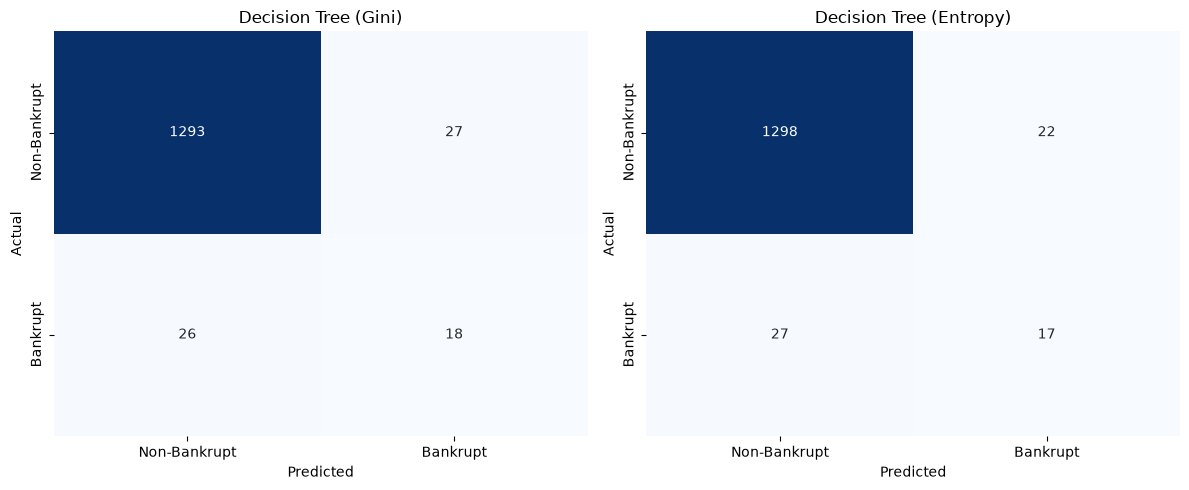

In [51]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gini = confusion_matrix(y_test, gini_pred)
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Bankrupt', 'Bankrupt'],
            yticklabels=['Non-Bankrupt', 'Bankrupt'],
            ax=axes[0], cbar=False)
axes[0].set_title('Decision Tree (Gini)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_entropy = confusion_matrix(y_test, entropy_pred)
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Bankrupt', 'Bankrupt'],
            yticklabels=['Non-Bankrupt', 'Bankrupt'],
            ax=axes[1], cbar=False)
axes[1].set_title('Decision Tree (Entropy)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

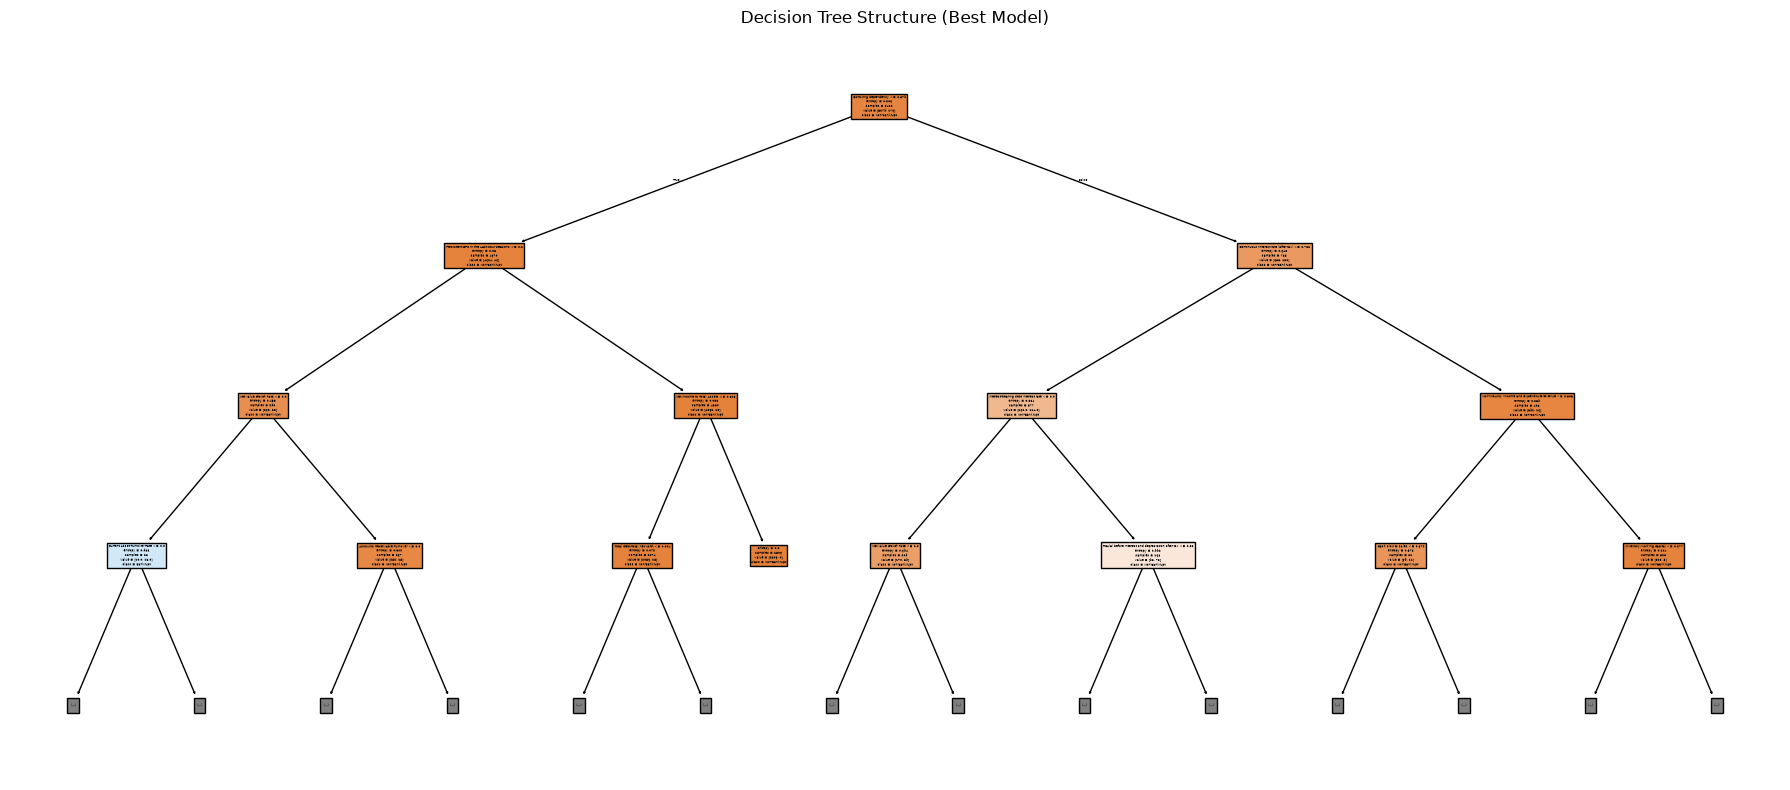

In [52]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

from sklearn import tree

best_model = dt_gini if accuracy_score(y_test, gini_pred) >= accuracy_score(y_test, entropy_pred) else dt_entropy

plt.figure(figsize=(18, 8))
tree.plot_tree(best_model, feature_names=X.columns, class_names=['Non-Bankrupt', 'Bankrupt'], max_depth=3, filled=True)
plt.title('Decision Tree Structure (Best Model)')
plt.tight_layout()
plt.show()

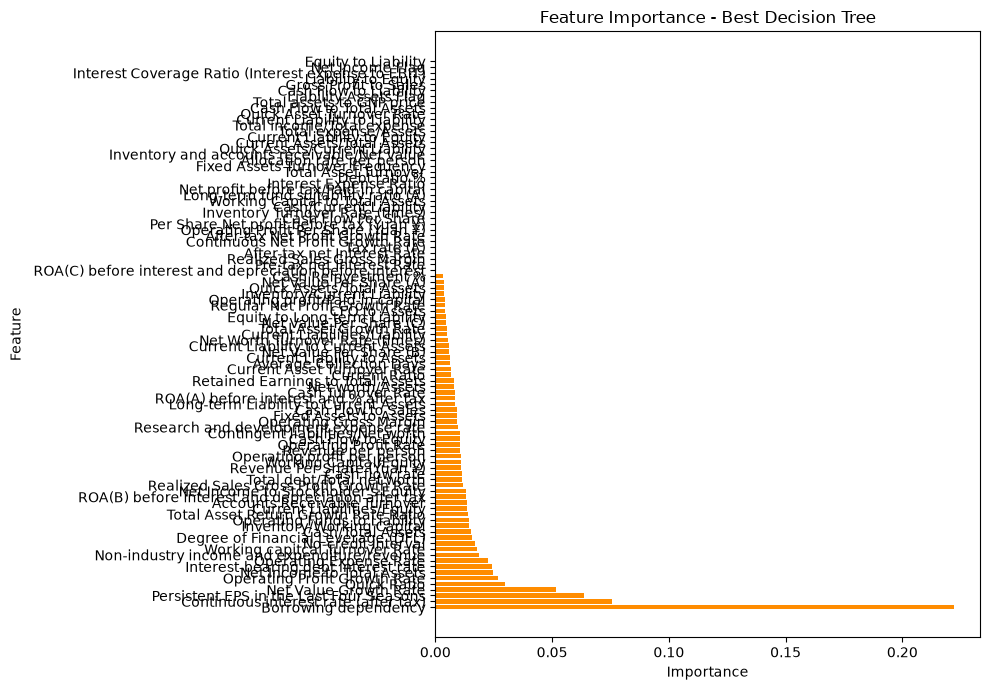

In [53]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='darkorange')
plt.title('Feature Importance - Best Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 5. Analisis

Pada eksperimen menggunakan Gini dan Entropy, kriteria Entropy menghasilkan accuracy, precision, dan F1-score yang lebih tinggi daripada kriteria Gini, walaupun memiliki nilai recall yang lebih buruk. 

Pada kedalaman 5, akurasi test mengalami penurunan, menunjukkan gejala overfitting. 

Berdasarkan grafik feature importance, fitur "Borrowing dependency" memiliki nilai importance yang dominan dibandingkan dengan fitur yang lain.

# 6. Kesimpulan dan Saran

Kesimpulan: pemilihan kriteria untuk algoritma Decision Tree berpengaruh dalam hasil prediksi dan tingkat kedalaman dari Decision Tree perlu diatur sedemikian rupa agar menghasilkan akurasi training dan test yang optimal.

Saran: Datasetnya terlalu imbalance.